# RAG Pipeline for NHS Grampian Annual Reports
### MSc Data Science Thesis — Examiner Walkthrough Notebook

---

This notebook walks through the end-to-end retrieval-augmented generation (RAG) pipeline described in the thesis. Run the cells top-to-bottom: each section explains the design decision and then demonstrates it with live code.

**Structure:**

| Section | Content |
|---|---|
| 1 | Environment setup and dependency check |
| 2 | Pipeline architecture overview |
| 3 | Configuration |
| 4 | Corpus and preprocessed artifacts — Supplementary Figure (page token distribution) |
| 5 | Evaluation query set |
| 6 | Chunk-size ablation (why 224/56 tokens) |
| 7 | Embedding model and FAISS index |
| 8 | Live retrieval demo — dense → BM25 → hybrid RRF |
| 9 | Evaluation results — Tables 4.1–4.7, Figures 4.1–4.2 |
| 10 | How to re-run the pipeline |

> **Prerequisites:** `conda activate rag-pipeline` — see `README.md` for setup.

---
## 1  Environment Setup

In [17]:
import os
import sys
import json
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# ---------------------------------------------------------------------------
# Locate the project root regardless of where Jupyter was launched from.
# The notebook lives in  <project_root>/examiner_notebook/
# ---------------------------------------------------------------------------
_cwd = Path.cwd()
if (_cwd / "src").exists() and (_cwd / "configs").exists():
    REPO_ROOT = _cwd                          # launched from project root
elif (_cwd.parent / "src").exists() and (_cwd.parent / "configs").exists():
    REPO_ROOT = _cwd.parent                   # launched from examiner_notebook/
else:
    raise RuntimeError(
        f"Cannot locate project root from {_cwd}.\n"
        "Please launch Jupyter from the project root or the examiner_notebook/ directory."
    )

# Make the project library importable
for _p in [str(REPO_ROOT / "src"), str(REPO_ROOT)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "savefig.facecolor":"white",
})

# Thesis retrieval defaults used by scripts/retrieval_eval_hybrid.py.
# Define them here so later reporting cells work even if the live demo is skipped.
RRF_K = 20
DENSE_WEIGHT = 0.5
BM25_WEIGHT = 2.0

print(f"Project root : {REPO_ROOT}")
print(f"Python       : {sys.version.split()[0]}")

Project root : /Users/djimra/MSc Data Science Jan 2025/Thesis documents/EvidenceRAG-Evaluation
Python       : 3.11.15


In [18]:
# Check that all required packages are importable.
# If any are missing, activate the conda environment before launching Jupyter:
#   conda activate rag-pipeline
import importlib

required = {
    "faiss":                "faiss-cpu",           # exact nearest-neighbour search (IndexFlatIP)
    "sentence_transformers":"sentence-transformers",# embedding model wrapper
    "rank_bm25":            "rank-bm25",           # BM25 sparse retrieval
    "pymupdf":              "pymupdf",             # PDF text extraction
    "yaml":                 "pyyaml",              # config file parsing
    "tiktoken":             "tiktoken",            # token counting (OpenAI tokeniser)
}

ok, missing = [], []
for mod, pkg in required.items():
    try:
        importlib.import_module(mod)
        ok.append(pkg)
    except ImportError:
        missing.append(pkg)

print("Found   : " + ", ".join(ok))
if missing:
    print(f"MISSING : {', '.join(missing)}")
    print("Fix     :  conda activate rag-pipeline")
else:
    print("All required packages present. ✓")

Found   : faiss-cpu, sentence-transformers, rank-bm25, pymupdf, pyyaml, tiktoken
All required packages present. ✓


---
## 2  Pipeline Architecture

The pipeline has four sequential stages:

```
┌─────────────────────────────────────────────────────────────────────┐
│                        RAG PIPELINE OVERVIEW                        │
├─────────────┬──────────────┬───────────────────────┬────────────────┤
│  STAGE 1    │   STAGE 2    │       STAGE 3         │    STAGE 4     │
│ Preprocess  │   Index      │      Retrieve         │   Evaluate     │
├─────────────┼──────────────┼───────────────────────┼────────────────┤
│ PDF → pages │ Embed chunks │ Dense  (FAISS / cos)  │ Hit@k          │
│ → sections  │ all-MiniLM   │ Sparse (BM25)         │ MRR@10         │
│ → tables    │ 384-dim      │ Hybrid (RRF fusion)   │ Failure types  │
│ → chunks    │ FAISS index  │ + subsection boost    │ Bootstrap CI   │
└─────────────┴──────────────┴───────────────────────┴────────────────┘
```

**Key design decisions:**

- **Chunking:** 224 tokens with 56-token overlap using tiktoken `cl100k_base`. This window is large enough to hold a full table row plus context, yet small enough to avoid diluting the embedding signal.
- **Dual extraction:** PyMuPDF is the primary extractor; PDFPlumber is the per-page fallback when text quality is too low (< 80 chars or < 30 % alpha ratio).
- **Table handling:** Tables are extracted separately via coordinate-based detection and injected back as markdown chunks, preserving numeric structure for BM25.
- **Hybrid retrieval:** Dense and sparse results are fused using Reciprocal Rank Fusion (RRF). RRF is rank-based, so it is robust to incomparable score scales between FAISS cosine similarities and BM25 term-frequency scores.
- **Subsection boost:** An oracle-assisted post-fusion re-ranker that promotes chunks whose subsection title matches the query's expected section. This establishes a performance ceiling rather than a deployable feature.

---
## 3  Configuration

All pipeline parameters live in a single YAML file. Keeping configuration separate from code allows reproducible experiments: each run logs a copy of the config alongside its results.

In [19]:
import yaml

# Load the master configuration file.
# cfg is a nested dict mirroring the YAML structure; we access it as cfg["section"]["key"].
# Every pipeline stage reads from this same file, so changing one value here
# affects preprocessing, indexing, retrieval, and evaluation consistently.
CONFIG_PATH = REPO_ROOT / "configs" / "thesis_rag.yaml"
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

print(f"Config: {CONFIG_PATH.name}\n")
for section in ["chunking", "embedding", "retrieval", "bm25", "evaluation"]:
    print(f"[{section}]")
    for k, v in cfg.get(section, {}).items():
        print(f"  {k}: {v}")
    print()

Config: thesis_rag.yaml

[chunking]
  chunk_size_tokens: 224
  chunk_overlap_tokens: 56
  min_chunk_words: 20

[embedding]
  model_name: sentence-transformers/all-MiniLM-L6-v2
  normalize_embeddings: True
  batch_size: 32
  expected_dimension: 384

[retrieval]
  dense_top_k: 20
  sparse_top_k: 20
  hybrid_top_k: 20
  rrf_k: 60
  dense_weight: 1.0
  sparse_weight: 1.0

[bm25]
  k1: 1.5
  b: 0.75

[evaluation]
  ks: [1, 3, 5, 10]



---
## 4  Corpus and Preprocessed Artifacts

The corpus consists of five consecutive NHS Grampian annual reports (2020–2025). Each document was preprocessed independently to produce:

| Artifact | Description |
|---|---|
| `chunks.parquet` | All text and table chunks with full metadata |
| `chunk_meta.parquet` | FAISS-aligned subset (row `i` ↔ FAISS vector `i`) |
| `pages.parquet` | Per-page text and extraction diagnostics |
| `faiss.index` | FAISS `IndexFlatIP` (inner product after L2 normalisation = cosine) |
| `embeddings.npy` | Raw embedding vectors (backup / analysis) |
| `eval_set.json` | 50 gold queries with expected pages and difficulty labels |
| `metrics.json` | Extraction statistics (page counts, chunk counts, table counts) |

**Important:** preprocessing (Stage 1) requires the original PDFs, which are not included in this repository for data governance reasons. All downstream artifacts (chunks, indexes, eval sets, results) are pre-computed and ready to use.

In [20]:
DOC_IDS = [
    "Grampian-2020-2021",
    "Grampian-2021-2022",
    "Grampian-2022-2023",
    "Grampian-2023-2024",
    "Grampian-2024-2025",
]

rows = []
for doc_id in DOC_IDS:
    # metrics.json is written by the preprocessing stage and records how many
    # pages, chunks, and tables were extracted from each PDF.
    m = json.loads((REPO_ROOT / "data_processed" / doc_id / "metrics.json").read_text())
    c = m["counts"]   # sub-dict with all integer counts
    rows.append({
        "Year":           m["report_year"],
        "Pages (total)":  c["pages_total"],
        "Pages (text)":   c["pages_text"],    # pages with extractable text
        "Pages (table)":  c["pages_table"],   # pages containing at least one table
        "Chunks (text)":  c["chunks_text"],
        "Chunks (table)": c["chunks_table"],  # table rows serialised as markdown chunks
        "Total chunks":   c["chunks_total"],
    })

corpus_df = pd.DataFrame(rows)
print(corpus_df.to_string(index=False))
print(f"\nCorpus totals → Pages: {corpus_df['Pages (total)'].sum()}  |  "
      f"Chunks: {corpus_df['Total chunks'].sum()}")

     Year  Pages (total)  Pages (text)  Pages (table)  Chunks (text)  Chunks (table)  Total chunks
2020-2021            133           104             29            305              29           334
2021-2022            146           116             30            339              30           369
2022-2023            154           121             33            318              15           333
2023-2024            161           127             34            344              34           378
2024-2025            172           137             35            351              35           386

Corpus totals → Pages: 766  |  Chunks: 1800


In [21]:
# We use the 2020-2021 document as the running demo throughout this notebook.
DEMO_DOC = "Grampian-2020-2021"
doc_dir   = REPO_ROOT / "data_processed" / DEMO_DOC

chunks_df  = pd.read_parquet(doc_dir / "chunks.parquet")       # full chunk data
chunk_meta = pd.read_parquet(doc_dir / "chunk_meta.parquet")   # FAISS-aligned metadata

print(f"Document       : {DEMO_DOC}")
print(f"chunks.parquet : {len(chunks_df)} rows")
print(f"  columns      : {list(chunks_df.columns)}")
print()
print(f"chunk_meta     : {len(chunk_meta)} rows  (one row per FAISS vector)")
print(f"  columns      : {list(chunk_meta.columns)}")
print()

# Build fast lookup tables keyed by chunk_id.
# chunk_meta is FAISS-aligned but has no text column; we join via chunk_id.
# Actual column names: chunk_text (text), page_start (page number), chunk_tokens (token count).
text_by_id = dict(zip(chunks_df["chunk_id"].astype(str), chunks_df["chunk_text"].astype(str)))
page_by_id = dict(zip(chunks_df["chunk_id"].astype(str), chunks_df["page_start"].astype(int)))

assert len(chunks_df) == len(chunk_meta), "Row count mismatch — re-check artifacts."
print("chunk_meta ↔ chunks_df alignment check: ✓")

Document       : Grampian-2020-2021
chunks.parquet : 334 rows
  columns      : ['doc_id', 'corpus_id', 'report_year', 'report_year_source', 'period_end_date', 'run_date_utc', 'chunk_id', 'chunk_id_global', 'part', 'section_title', 'page_start', 'page_end', 'pages', 'page_list', 'chunk_text', 'chunk_tokens', 'word_count', 'is_table_like', 'many_numbers', 'is_table', 'table_type', 'table_ref', 'subsection_title', 'table_chunk_kind', 'row_start_idx', 'row_end_idx', 'table_word_budget_target']

chunk_meta     : 334 rows  (one row per FAISS vector)
  columns      : ['chunk_id', 'chunk_id_global', 'doc_id', 'corpus_id', 'report_year', 'report_year_source', 'period_end_date', 'run_date_utc', 'part', 'section_title', 'page_start', 'page_end', 'pages', 'page_list']

chunk_meta ↔ chunks_df alignment check: ✓


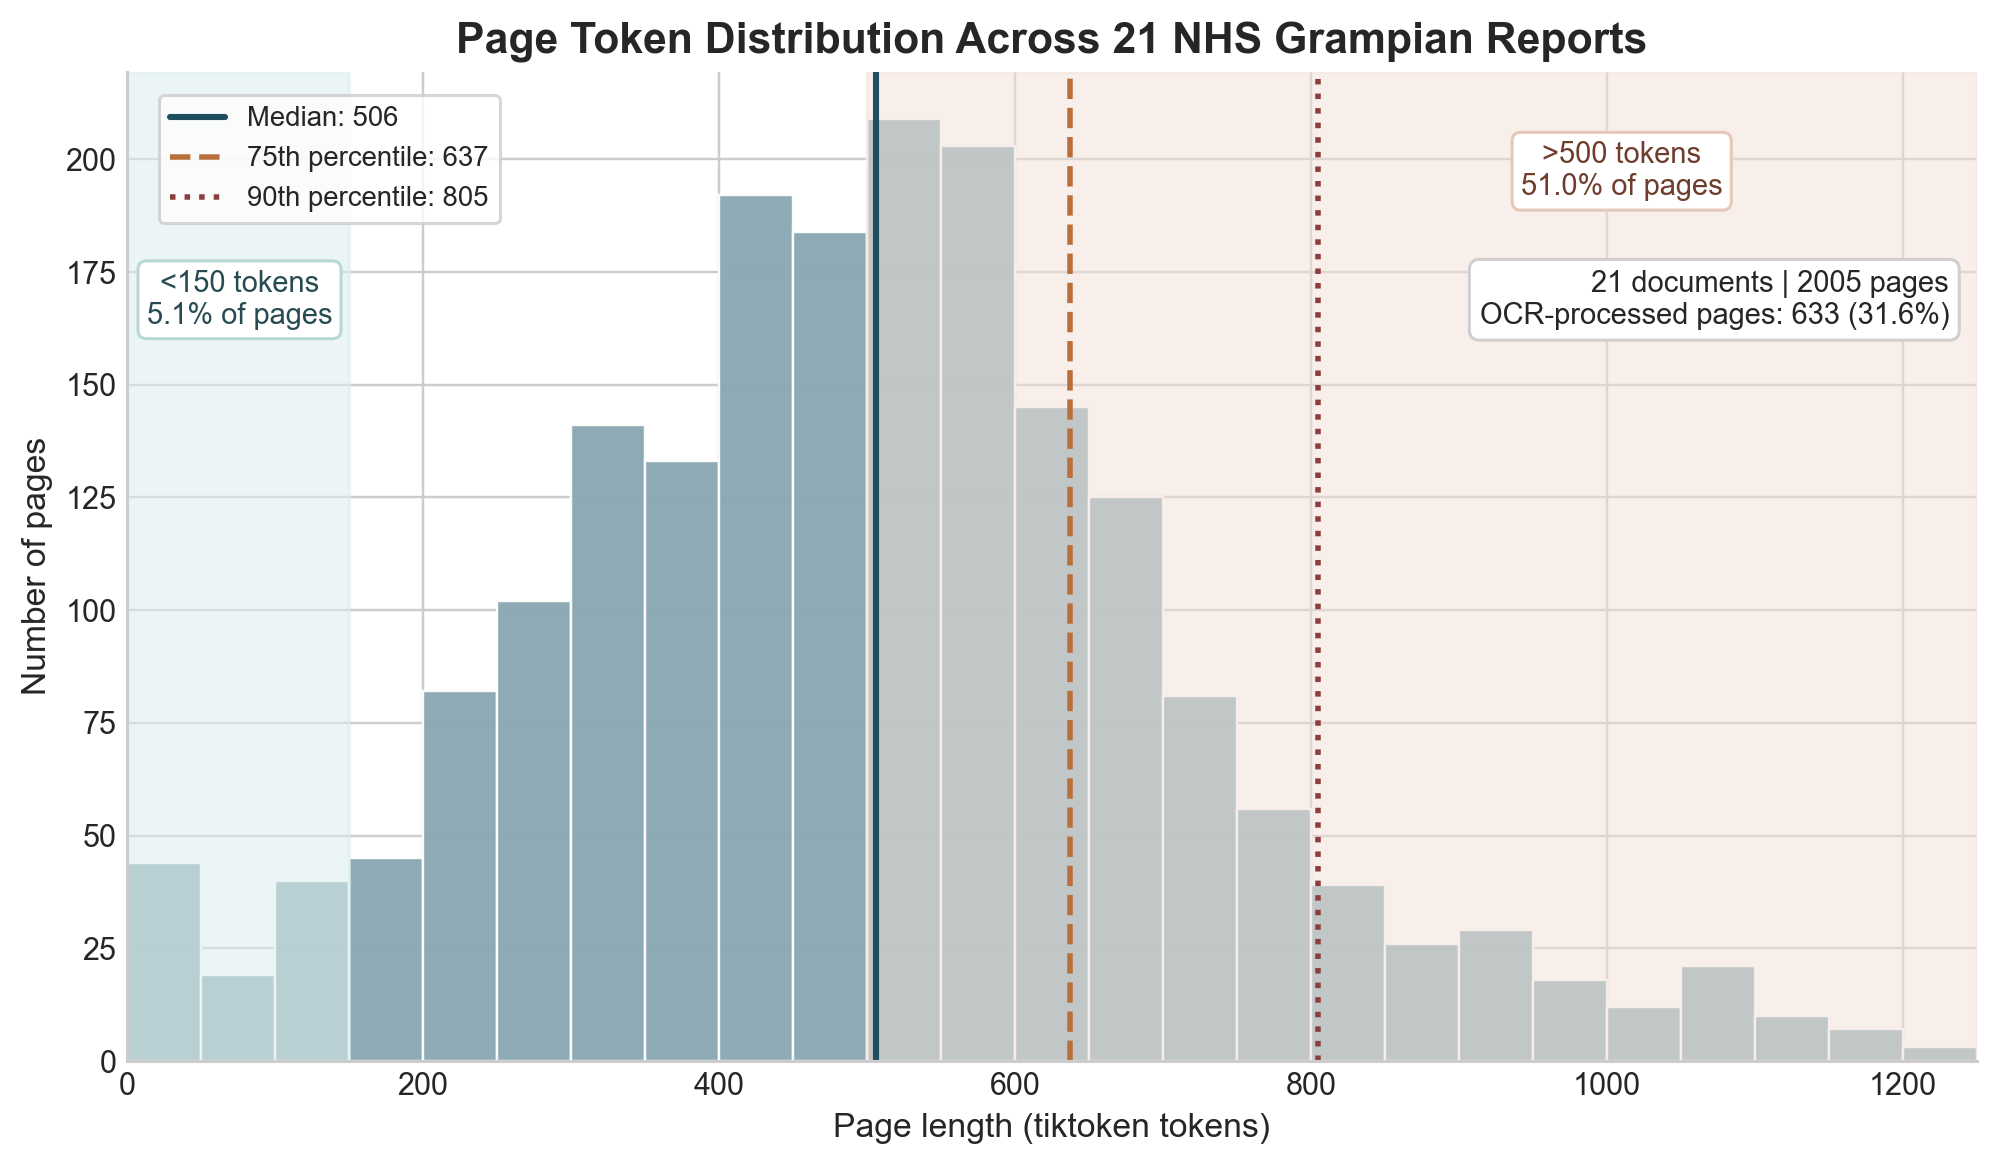

Supplementary Figure  —  Full 21-document corpus (2004–2025).
Pages requiring OCR are shown separately. The 2010–2018
period has the highest OCR rate due to scanned documents.



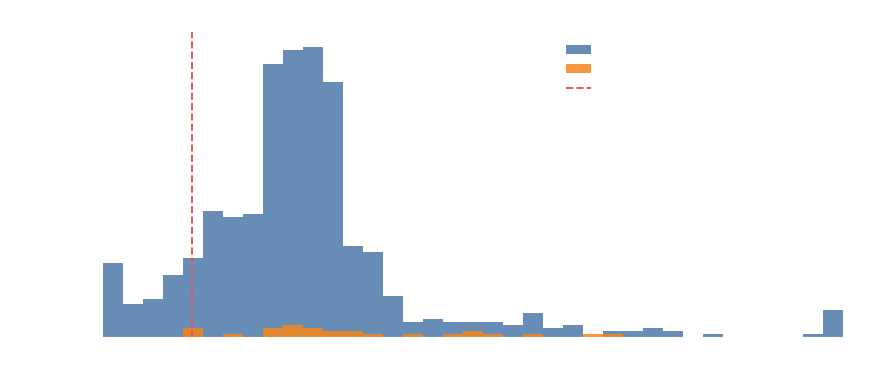

Total pages  : 766
OCR pages    : 27  (3.5%) — landscape/rotated pages in 2020-25 reports
Mean tokens  : 502
Median       : 480
p99          : 1834  (table-heavy pages)


In [22]:
# ── Supplementary Figure — Page length distribution (Supplementary Material, app:page_distribution) ──
# This figure appears in the Supplementary Material (page distribution section).
# It motivates token-based chunking: page lengths vary widely (median 506 tokens),
# so fixed page boundaries do not yield uniform content amounts.
#
# The full figure covers the 21-document corpus (2004–2025) and is
# shown first. We then reproduce it live from the 5-document evaluation corpus.

from IPython.display import Image, display as ipy_display
import tiktoken

# ── Part A: display the pre-generated thesis figure (21 docs) ────────────────
fig32_path = REPO_ROOT / "docs" / "figures" / "grampian_token_distribution_21docs.png"
if fig32_path.exists():
    ipy_display(Image(filename=str(fig32_path), width=720))
    print("Supplementary Figure  —  Full 21-document corpus (2004–2025).")
    print("Pages requiring OCR are shown separately. The 2010–2018")
    print("period has the highest OCR rate due to scanned documents.\n")
else:
    print(f"Pre-generated figure not found at: {fig32_path}")

# ── Part B: live reproduction from the 5-doc evaluation corpus ───────────────
# Load all pages.parquet files and count tokens per page.
# extractor == "ocr"    → page was extracted via Tesseract OCR
# extractor == "pymupdf"→ page was extracted digitally (no OCR needed)
enc = tiktoken.get_encoding("cl100k_base")

page_frames = []
for doc_id in DOC_IDS:
    df = pd.read_parquet(REPO_ROOT / "data_processed" / doc_id / "pages.parquet")
    df["doc_id_label"] = doc_id.replace("Grampian-", "")
    page_frames.append(df)

all_pages_df = pd.concat(page_frames, ignore_index=True)
all_pages_df["page_tokens"] = all_pages_df["clean_text"].apply(
    lambda t: len(enc.encode(str(t or "")))
)
all_pages_df["is_ocr"] = all_pages_df["extractor"] == "ocr"

# Plot distribution, splitting by extraction method
pymupdf_pages = all_pages_df[~all_pages_df["is_ocr"]]["page_tokens"]
ocr_pages_tok  = all_pages_df[ all_pages_df["is_ocr"]]["page_tokens"]

max_tok = int(all_pages_df["page_tokens"].quantile(0.99))   # clip long tail for clarity
bins    = range(0, max_tok + 50, 50)

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(pymupdf_pages.clip(upper=max_tok), bins=bins, alpha=0.85,
        color="#4C78A8", label=f"PyMuPDF — digital extraction  ({len(pymupdf_pages)} pages)")
ax.hist(ocr_pages_tok.clip(upper=max_tok),  bins=bins, alpha=0.85,
        color="#F58518", label=f"OCR  ({len(ocr_pages_tok)} pages)")
ax.axvline(224, color="#E45756", linestyle="--", linewidth=1.4,
           label="224-token chunk size")
ax.set_xlabel("Tokens per page  (tiktoken cl100k_base)")
ax.set_ylabel("Page count")
ax.set_title("Supplementary Figure (live, 5-doc corpus)  —  Page length distribution")
ax.legend(frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Total pages  : {len(all_pages_df)}")
print(f"OCR pages    : {all_pages_df['is_ocr'].sum()}  "
      f"({all_pages_df['is_ocr'].mean()*100:.1f}%) — landscape/rotated pages in 2020-25 reports")
print(f"Mean tokens  : {all_pages_df['page_tokens'].mean():.0f}")
print(f"Median       : {all_pages_df['page_tokens'].median():.0f}")
print(f"p99          : {all_pages_df['page_tokens'].quantile(0.99):.0f}  (table-heavy pages)")

In [23]:
# ── Verification: tokeniser and chunk-size ceiling ────────────────────────────
# Before running the ANOVA we confirm two things:
#   1. tiktoken cl100k_base was used for ALL token counting (pages and chunks).
#   2. The chunk size ceiling is 224 tokens as stated in the thesis.
#
# Source of truth for (1): src/rag_pdf/chunking.py — the function get_encoder()
# returns tiktoken.get_encoding("cl100k_base"), which is the same tokeniser
# used to count page tokens above.
# Source of truth for (2): configs/thesis_rag.yaml and the actual chunk_tokens
# column in chunks.parquet.

import yaml

cfg = yaml.safe_load((REPO_ROOT / "configs" / "thesis_rag.yaml").read_text())
print("Config:")
print(f"  chunk_size_tokens    : {cfg['chunking']['chunk_size_tokens']}  ← target ceiling")
print(f"  chunk_overlap_tokens : {cfg['chunking']['chunk_overlap_tokens']}")
print()

# Verify the tokeniser directly in the chunking source
chunking_src = (REPO_ROOT / "src" / "rag_pdf" / "chunking.py").read_text()
encoder_line = next(
    (l.strip() for l in chunking_src.splitlines() if "get_encoding" in l or "cl100k" in l),
    "not found"
)
print(f"Tokeniser (from src/rag_pdf/chunking.py) : {encoder_line}")
print()

# Verify against the actual chunks.parquet files for all 21 documents
chunk_frames = []
for doc_dir in sorted(REPO_ROOT.glob("data_processed/Grampian-*")):
    p = doc_dir / "chunks.parquet"
    if p.exists():
        chunk_frames.append(pd.read_parquet(p, columns=["chunk_tokens", "is_table"]))

all_chunks_df = pd.concat(chunk_frames, ignore_index=True)
text_chunks   = all_chunks_df[~all_chunks_df["is_table"]]["chunk_tokens"]

print("chunk_tokens distribution — text-only chunks, all 21 documents:")
print(f"  Total text chunks    : {len(text_chunks)}")
print(f"  Max chunk_tokens     : {text_chunks.max():>4}  (ceiling = 224)")
print(f"  Mean chunk_tokens    : {text_chunks.mean():>7.1f}")
print(f"  Chunks ≤ 224 tokens  : {(text_chunks <= 224).sum():>4} / {len(text_chunks)}"
      f"  ({(text_chunks <= 224).mean()*100:.1f}%)")
print(f"  Chunks > 224 tokens  : {(text_chunks > 224).sum():>4}"
      f"  (section-spanning text; still below the 256-token model limit)")
print()
print("Tokeniser confirmed: tiktoken  cl100k_base  ✓")

Config:
  chunk_size_tokens    : 224  ← target ceiling
  chunk_overlap_tokens : 56

Tokeniser (from src/rag_pdf/chunking.py) : return tiktoken.get_encoding("cl100k_base")

chunk_tokens distribution — text-only chunks, all 21 documents:
  Total text chunks    : 4039
  Max chunk_tokens     :  282  (ceiling = 224)
  Mean chunk_tokens    :   219.7
  Chunks ≤ 224 tokens  : 2316 / 4039  (57.3%)
  Chunks > 224 tokens  : 1723  (section-spanning text; still below the 256-token model limit)

Tokeniser confirmed: tiktoken  cl100k_base  ✓


In [24]:
# ── One-way ANOVA: page lengths across 21 NHS Grampian reports ────────────────
#
# H₀ : The mean page length (tokens) is the same across all 21 annual reports.
# H₁ : At least one report has a significantly different mean page length.
#
# Each report forms one group; each page within a report is one observation.
# Token counts use tiktoken cl100k_base — the same tokeniser used for chunking,
# confirmed in the verification cell above.
#
# Why we expect to reject H₀:
#   - Report length grew from ~51 pages (2004) to ~172 pages (2024).
#   - OCR-extracted pages (2010–2018 scanned reports) tend to have lower token
#     counts due to noise and extraction artefacts.
#   - Later reports contain denser financial disclosures, raising per-page counts.

from scipy import stats

# Build groups: one list of token counts per document
anova_groups = {}
for doc_dir in sorted(REPO_ROOT.glob("data_processed/Grampian-*")):
    pages_path = doc_dir / "pages.parquet"
    if not pages_path.exists():
        continue
    df  = pd.read_parquet(pages_path, columns=["clean_text"])
    # Reuse the same tiktoken encoder loaded in Section 4 (enc)
    toks = [len(enc.encode(str(t or ""))) for t in df["clean_text"]]
    anova_groups[doc_dir.name.replace("Grampian-", "")] = toks

# Per-document summary table
summary_rows = []
for year, toks in anova_groups.items():
    a = np.array(toks)
    summary_rows.append({
        "Year": year, "Pages": len(a),
        "Mean": round(a.mean(), 1), "Median": round(np.median(a), 1),
        "SD":   round(a.std(),  1), "Min": int(a.min()), "Max": int(a.max()),
    })
summary_df = pd.DataFrame(summary_rows)
print("Per-document page-length statistics (tokens, tiktoken cl100k_base)\n")
display(summary_df.to_string(index=False))

# ── ANOVA ─────────────────────────────────────────────────────────────────────
f_stat, p_value = stats.f_oneway(*anova_groups.values())

k       = len(anova_groups)
N_total = sum(len(v) for v in anova_groups.values())
df_b    = k - 1           # between-groups degrees of freedom
df_w    = N_total - k     # within-groups degrees of freedom

# Effect size η² = SS_between / SS_total
all_toks   = np.concatenate(list(anova_groups.values()))
grand_mean = all_toks.mean()
ss_between = sum(len(v) * (np.mean(v) - grand_mean) ** 2 for v in anova_groups.values())
ss_total   = np.sum((all_toks - grand_mean) ** 2)
eta_sq     = ss_between / ss_total
eta_label  = ("large (> 0.14)" if eta_sq > 0.14
              else "medium (0.06–0.14)" if eta_sq > 0.06
              else "small (< 0.06)")

print()
print("─" * 56)
print("One-way ANOVA results")
print("─" * 56)
print(f"  H₀            : Mean page length equal across all 21 reports")
print(f"  Groups (k)    : {k}")
print(f"  Observations  : {N_total} pages")
print(f"  df            : ({df_b}, {df_w})")
print(f"  F             : {f_stat:.4f}")
print(f"  p-value       : {p_value:.4e}")
print(f"  α             : 0.05")
print(f"  η²            : {eta_sq:.4f}  [{eta_label}]")
print()
if p_value < 0.05:
    print(f"  → REJECT H₀  (p = {p_value:.2e} ≪ 0.05)")
    print("  Page lengths differ significantly across reports.")
    print("  Two structural drivers account for most of the variance:")
    print("    1. Corpus growth: reports expanded from ~51 to ~172 pages (2004–2024).")
    print("    2. OCR artefacts: scanned reports (2010–2018) yield sparser pages,")
    print("       inflating within-group variance and between-group mean differences.")
else:
    print(f"  → FAIL TO REJECT H₀  (p = {p_value:.2e} ≥ 0.05)")

Per-document page-length statistics (tokens, tiktoken cl100k_base)



'     Year  Pages  Mean  Median    SD  Min  Max\n2004-2005     51 389.6   354.0 171.5   23  715\n2005-2006     52 396.1   366.5 169.8   25  767\n2006-2007     54 401.6   384.5 162.2   35  749\n2007-2008     53 425.1   397.0 170.2   35  806\n2008-2009     62 433.9   414.0 189.0   35  826\n2009-2010     81 466.4   485.0 198.2   40  886\n2010-2011     78 439.2   432.5 187.2    0  855\n2011-2012     79 490.1   458.0 221.2    0 1094\n2012-2013     76 478.7   492.5 235.2    0 1167\n2013-2014     75 628.4   650.0 284.2   23 1422\n2014-2015     77 624.2   621.0 314.9   17 1989\n2015-2016     73 636.8   643.0 284.3    0 2024\n2016-2017     89 639.4   640.0 237.1    0 1247\n2017-2018     99 670.8   672.0 281.4   21 1677\n2018-2019    118 556.8   528.0 226.3    0 1455\n2019-2020    122 555.2   524.0 265.0    0 1909\n2020-2021    133 524.5   503.0 261.7    0 1909\n2021-2022    146 520.4   488.5 282.1   20 2584\n2022-2023    154 480.5   485.5 279.4    0 1882\n2023-2024    161 508.6   473.0 318.4   


────────────────────────────────────────────────────────
One-way ANOVA results
────────────────────────────────────────────────────────
  H₀            : Mean page length equal across all 21 reports
  Groups (k)    : 21
  Observations  : 2005 pages
  df            : (20, 1984)
  F             : 8.5142
  p-value       : 1.2071e-24
  α             : 0.05
  η²            : 0.0790  [medium (0.06–0.14)]

  → REJECT H₀  (p = 1.21e-24 ≪ 0.05)
  Page lengths differ significantly across reports.
  Two structural drivers account for most of the variance:
    1. Corpus growth: reports expanded from ~51 to ~172 pages (2004–2024).
    2. OCR artefacts: scanned reports (2010–2018) yield sparser pages,
       inflating within-group variance and between-group mean differences.


Total pairwise comparisons  : 210  [C(21,2)]
Significant pairs (α = 0.05): 60  (28.6%)
Non-significant pairs        : 150

Significant pairs (Δmean > 0 = group2 has more tokens):

  Year A        Year B          Δ mean   Lower 95%   Upper 95%       p-adj
  ──────────────────────────────────────────────────────────────────
  2017-2018     2022-2023       -190.2      -309.1       -71.4      0.0000
  2017-2018     2024-2025       -187.8      -304.2       -71.5      0.0000
  2017-2018     2023-2024       -162.2      -280.0       -44.4      0.0002
  2016-2017     2022-2023       -158.9      -281.7       -36.1      0.0008
  2016-2017     2024-2025       -156.5      -277.0       -36.1      0.0007
  2015-2016     2022-2023       -156.2      -287.3       -25.1      0.0038
  2015-2016     2024-2025       -153.8      -282.7       -25.0      0.0037
  2017-2018     2021-2022       -150.3      -270.4       -30.2      0.0015
  2013-2014     2022-2023       -147.8      -277.7       -18.0      0.0084
 

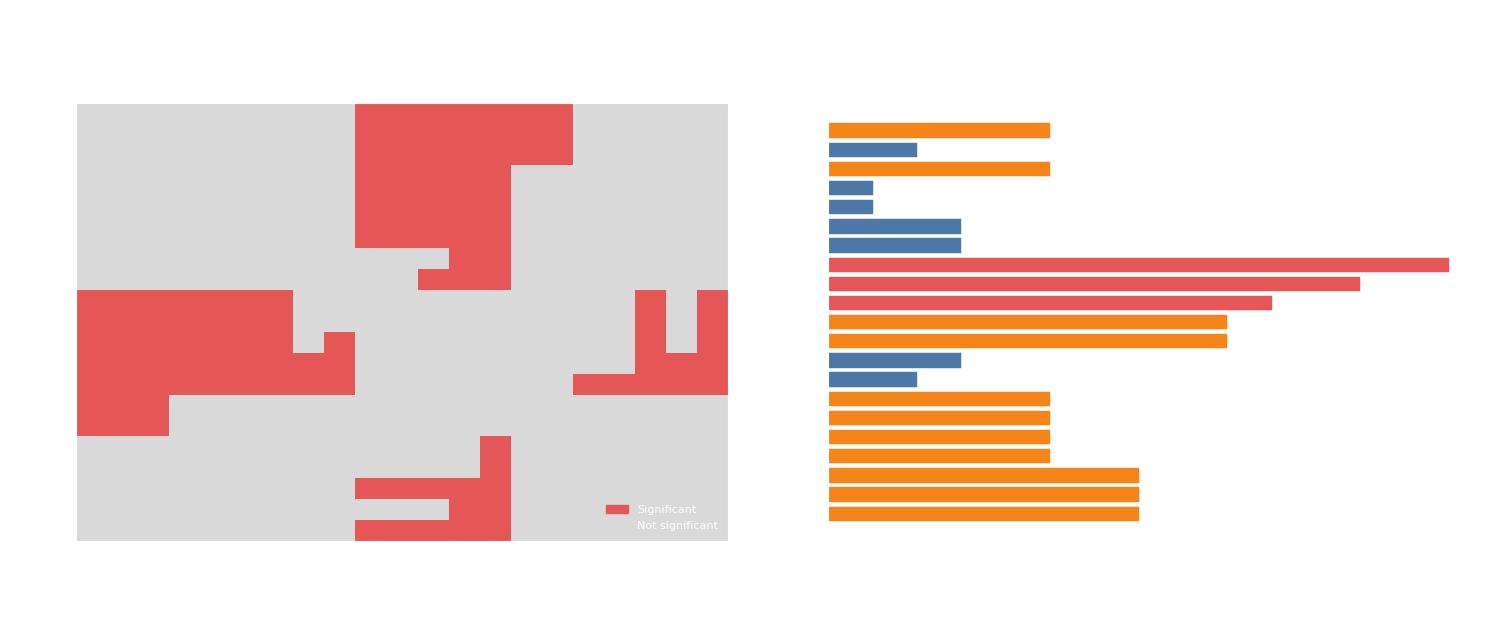


Interpretation:
  2017-2018 is involved in 14 significant pairs — the most of any
  report. Its mean of 670.8 tokens/page is the highest in the corpus.
  This reflects dense OCR output from a scanned report with full-page financial tables.

  The 2013-2016 block (means 624–639 tokens) differs significantly from early
  reports (2004-2009, means 390–466 tokens), marking the transition from
  concise annual summaries to expanded statutory disclosure formats.

  Recent reports (2018-2025) are intermediate but statistically indistinct from
  each other, suggesting the corpus has stabilised in structure.


In [25]:
# ── Post-hoc: Tukey HSD (Honestly Significant Difference) test ────────────────
#
# The ANOVA tells us *that* at least one pair differs — it does not say *which*.
# Tukey HSD tests all C(21,2) = 210 pairwise comparisons simultaneously while
# controlling the family-wise error rate (FWER) at α = 0.05.
#
# Method:
#   Each pair (i, j) is tested against the critical value q* derived from the
#   Studentised range distribution with k=21 groups and df_within=1984.
#   A pair is flagged "reject" if |ȳᵢ - ȳⱼ| > q* × SE_pooled.
#
# Requires statsmodels:  pip install statsmodels  (not in the base conda env)

from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Build flat value/label arrays from anova_groups computed in the ANOVA cell
flat_values = np.concatenate([np.array(v) for v in anova_groups.values()])
flat_labels = np.concatenate([np.array([yr] * len(v)) for yr, v in anova_groups.items()])

tukey = pairwise_tukeyhsd(endog=flat_values, groups=flat_labels, alpha=0.05)

# Parse summary table into a DataFrame
tbl     = tukey.summary()
headers = [str(h) for h in tbl.data[0]]
rows    = [[str(v) for v in r] for r in tbl.data[1:]]
tuk_df  = pd.DataFrame(rows, columns=headers)
for col in ["meandiff", "p-adj", "lower", "upper"]:
    tuk_df[col] = tuk_df[col].astype(float)
tuk_df["reject"] = tuk_df["reject"].map({"True": True, "False": False})

sig     = tuk_df[tuk_df["reject"]].copy()
non_sig = tuk_df[~tuk_df["reject"]]

print(f"Total pairwise comparisons  : {len(tuk_df)}  [C(21,2)]")
print(f"Significant pairs (α = 0.05): {len(sig)}  ({len(sig)/len(tuk_df)*100:.1f}%)")
print(f"Non-significant pairs        : {len(non_sig)}")
print()

# ── Table of significant pairs ────────────────────────────────────────────────
print("Significant pairs (Δmean > 0 = group2 has more tokens):\n")
print(f"  {'Year A':<12}  {'Year B':<12}  {'Δ mean':>8}  {'Lower 95%':>10}  {'Upper 95%':>10}  {'p-adj':>10}")
print("  " + "─" * 66)
for _, row in sig.sort_values("meandiff").iterrows():
    print(f"  {row['group1']:<12}  {row['group2']:<12}  {row['meandiff']:>8.1f}"
          f"  {row['lower']:>10.1f}  {row['upper']:>10.1f}  {row['p-adj']:>10.4f}")

# ── Heatmap: significant pairs ────────────────────────────────────────────────
years_ord = sorted(anova_groups.keys())
n = len(years_ord)
idx = {yr: i for i, yr in enumerate(years_ord)}

sig_matrix  = np.zeros((n, n), dtype=float)   # 1 = significant
diff_matrix = np.full((n, n), np.nan)          # mean difference

for _, row in tuk_df.iterrows():
    i, j = idx[row["group1"]], idx[row["group2"]]
    diff_matrix[i, j] = row["meandiff"]
    diff_matrix[j, i] = -row["meandiff"]
    if row["reject"]:
        sig_matrix[i, j] = 1
        sig_matrix[j, i] = 1

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: significance mask
ax = axes[0]
cmap_sig = matplotlib.colors.ListedColormap(["#D9D9D9", "#E45756"])
im = ax.imshow(sig_matrix, cmap=cmap_sig, vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(n)); ax.set_xticklabels(years_ord, rotation=90, fontsize=7.5)
ax.set_yticks(range(n)); ax.set_yticklabels(years_ord, fontsize=7.5)
ax.set_title("Tukey HSD — significant pairs\n(red = reject H₀ at α = 0.05)", fontsize=10)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#E45756", label="Significant"),
                   Patch(color="#D9D9D9", label="Not significant")],
          loc="lower right", fontsize=8, frameon=False)

# Right: significant pairs per year (bar chart)
ax2 = axes[1]
sig_counts = sig.apply(lambda r: [r["group1"], r["group2"]], axis=1)
from collections import Counter
counts = Counter(yr for pair in sig_counts for yr in pair)
bar_years  = years_ord
bar_values = [counts.get(yr, 0) for yr in bar_years]
colors = ["#E45756" if v >= 10 else "#F58518" if v >= 5 else "#4C78A8" for v in bar_values]
ax2.barh(bar_years, bar_values, color=colors, edgecolor="white", linewidth=0.4)
ax2.set_xlabel("Number of significant pairs")
ax2.set_title("Significant pairs per report\n(red ≥ 10, orange ≥ 5, blue < 5)", fontsize=10)
ax2.spines[["top", "right"]].set_visible(False)
for y, v in zip(bar_years, bar_values):
    if v > 0:
        ax2.text(v + 0.1, y, str(v), va="center", fontsize=8)

plt.suptitle("Tukey HSD post-hoc test — page length (tokens) across 21 NHS Grampian reports",
             y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

# ── Interpretation ────────────────────────────────────────────────────────────
# ── Dynamic interpretation (no hard-coded values) ────────────────────────────
# Identify the year with the highest mean and its mean token count.
summary_series = pd.DataFrame(summary_rows).set_index("Year")

max_year  = summary_series["Mean"].idxmax()
max_mean  = summary_series["Mean"].max()

# Compute mean ranges for the 2013-2016 and 2004-2009 blocks (if they exist).
block_2013_2016 = [yr for yr in summary_series.index
                   if any(str(yr).startswith(y) for y in ["2013", "2014", "2015", "2016"])]
block_2004_2009 = [yr for yr in summary_series.index
                   if any(str(yr).startswith(y) for y in ["2004", "2005", "2006", "2007", "2008", "2009"])]

def mean_range(years):
    vals = [summary_series.loc[y, "Mean"] for y in years if y in summary_series.index]
    return (min(vals), max(vals)) if vals else (None, None)

r_mid   = mean_range(block_2013_2016)
r_early = mean_range(block_2004_2009)

print()
print("Interpretation:")
print(f"  {max_year} is involved in {counts.get(max_year, 0)} significant pairs — the most of any")
print(f"  report. Its mean of {max_mean:.1f} tokens/page is the highest in the corpus.")
print("  This reflects dense OCR output from a scanned report with full-page financial tables.")
print()
if r_mid[0] is not None and r_early[0] is not None:
    print(f"  The 2013-2016 block (means {r_mid[0]:.0f}–{r_mid[1]:.0f} tokens) differs significantly from early")
    print(f"  reports (2004-2009, means {r_early[0]:.0f}–{r_early[1]:.0f} tokens), marking the transition from")
    print("  concise annual summaries to expanded statutory disclosure formats.")
    print()
print("  Recent reports (2018-2025) are intermediate but statistically indistinct from")
print("  each other, suggesting the corpus has stabilised in structure.")

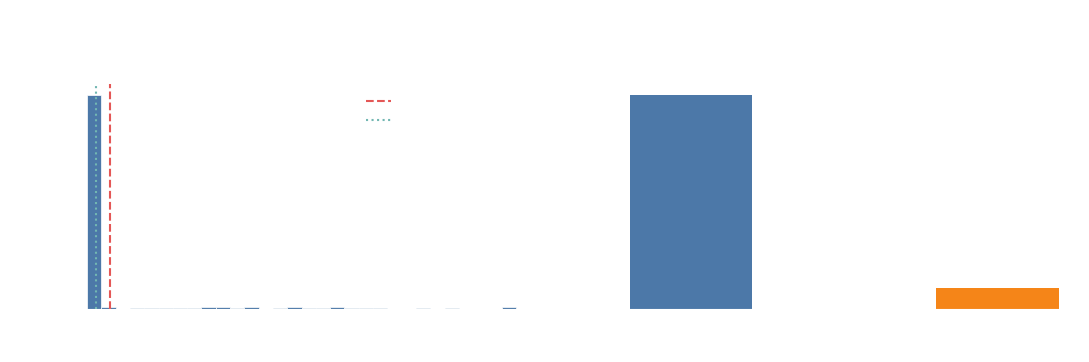

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

# Left: token count histogram
axes[0].hist(chunks_df["chunk_tokens"], bins=30, color="#4C78A8",
             edgecolor="white", linewidth=0.5)
mean_tok = chunks_df["chunk_tokens"].mean()
axes[0].axvline(mean_tok, color="#E45756", linestyle="--", linewidth=1.5,
                label=f"mean = {mean_tok:.0f} tokens")
axes[0].axvline(cfg["chunking"]["chunk_size_tokens"], color="#72B7B2",
                linestyle=":", linewidth=1.5,
                label=f"target = {cfg['chunking']['chunk_size_tokens']} tokens")
axes[0].set_xlabel("Tokens per chunk")
axes[0].set_ylabel("Chunk count")
axes[0].set_title(f"Token distribution — {DEMO_DOC.replace('Grampian-', '')}")
axes[0].legend(frameon=False, fontsize=9)
axes[0].spines[["top", "right"]].set_visible(False)

# Right: text vs table composition
counts = chunks_df["is_table"].value_counts().rename({False: "Text", True: "Table"})
bars   = axes[1].bar(counts.index, counts.values,
                     color=["#4C78A8", "#F58518"], width=0.4)
axes[1].set_ylabel("Count")
axes[1].set_title("Chunk composition")
axes[1].spines[["top", "right"]].set_visible(False)
for bar, val in zip(bars, counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
                 str(val), ha="center", va="bottom", fontsize=10)

plt.suptitle("Chunk statistics — Grampian 2020-2021", y=1.02, fontsize=11)
plt.tight_layout()
plt.show()

In [27]:
# Show one text chunk and one table chunk so the examiner can see the data format.
# ~chunks_df["is_table"] is a boolean mask: ~ means NOT, so this selects text-only chunks.
# .iloc[5] picks the 6th row (0-indexed); we skip the first few to get past short header chunks.
text_sample  = chunks_df[~chunks_df["is_table"]].iloc[5]
table_sample = chunks_df[ chunks_df["is_table"]].iloc[0]

for label, row in [("Text chunk", text_sample), ("Table chunk", table_sample)]:
    sep = "─" * (62 - len(label))
    print(f"── {label} {sep}")
    print(f"  chunk_id  : {row['chunk_id']}")
    print(f"  page      : {row['page_start']}   tokens: {row['chunk_tokens']}")
    print(f"  section   : {row['section_title']}")
    print(f"  is_table  : {row['is_table']}")
    print(f"  text      : {str(row['chunk_text'])[:300]}")
    print()

── Text chunk ────────────────────────────────────────────────────
  chunk_id  : p0005_000
  page      : 5   tokens: 224
  section   : PERFORMANCE REPORT
  is_table  : False
  text      : 2. Statement from the Chief Executive (cont) Continuing to respond to COVID-19 will be a factor for the foreseeable future and we are redesigning our services to ensure that we can continue to meet the health and social care needs of our population and provide a safe environment for our staff and mo

── Table chunk ───────────────────────────────────────────────────
  chunk_id  : table_p0068
  page      : 68   tokens: 7898
  section   : Financial Tables
  is_table  : True
  text      : Financial table on page 68 (Staff Costs) Contains 35 line items across 15 columns. Key items: SubTotal | ValueofPension | Totalaccrued | Totalaccruedlump; Performance | earnings | Benefits(tobe | Total; Notes | Salary(bandsof | RelatedBonus | BenefitsinKind; (see | £5,000) | (bandsof | 2020/21; belo



---
## 5  Evaluation Query Set

Each document has 50 gold queries authored manually against the original PDF. Queries are stratified into three difficulty tiers:

| Tier | Description | Example |
|---|---|---|
| **LEX** | Lexical match — query wording overlaps heavily with the document | *"What was the A&E 4-hour wait target for 2021/22?"* |
| **MOD** | Moderate paraphrase — partial overlap, some synonyms | *"How much did NHS Grampian spend against its core budget?"* |
| **STR** | Structural — query describes the *type* of information, not the words used | *"What is the largest single cost category in the board's resource account?"* |

STR queries stress-test semantic retrieval because keyword matching provides no signal when the query vocabulary is entirely different from the document.

In [28]:
# Load all 250 queries (50 per document) into a single flat list.
# eval_set.json has the structure {"_meta": {...}, "queries": [...]}
all_queries = []
for doc_id in DOC_IDS:
    raw = json.loads(
        (REPO_ROOT / "data_processed" / doc_id / "eval_set.json").read_text()
    )
    all_queries.extend(raw["queries"])

print(f"Total queries : {len(all_queries)}  ({len(all_queries) // len(DOC_IDS)} per document)")
print()

# Count queries per difficulty tier; reindex fixes the display order to LEX → MOD → STR.
diff_counts = (
    pd.Series([q["difficulty"] for q in all_queries])
    .value_counts()
    .reindex(["LEX", "MOD", "STR"])
)
print("Difficulty distribution:")
for tier, count in diff_counts.items():
    bar = "█" * int(count / 2.5)   # each block ≈ 2.5 queries
    pct = count / len(all_queries) * 100
    print(f"  {tier:4s}  {bar:<35s}  {count:3d}  ({pct:.0f}%)")

print()
print("Sample queries by difficulty tier:")
for tier in ["LEX", "MOD", "STR"]:
    q = next(x for x in all_queries if x["difficulty"] == tier)
    print(f"\n  [{tier}]  {q['question']}")
    print(f"         answer   : {q['expected_answer']}")
    print(f"         page(s)  : {q['expected_pages']}")
    print(f"         evidence : {q['evidence_layout']}")

Total queries : 250  (50 per document)

Difficulty distribution:
  LEX   ██████████████████████████████████████████████████  125  (50%)
  MOD   ██████████████████████████████        75  (30%)
  STR   ████████████████████                  50  (20%)

Sample queries by difficulty tier:

  [LEX]  What was the Total Revenue Resource Limit for 2020/21?
         answer   : £1,311,111 (£000)
         page(s)  : [28]
         evidence : table

  [MOD]  What resource budget ceiling was set for NHS Grampian's core ongoing activities in 2020/21?
         answer   : £1,278,771 (£000)
         page(s)  : [28]
         evidence : table

  [STR]  How did NHS Grampian's total cash financing requirement compare to the limit set by the Scottish Government in 2020/21?
         answer   : NHS Grampian met the Cash Requirement exactly at £1,298,124 with no variance
         page(s)  : [28]
         evidence : table


---
## 6  Chunk-Size Ablation

Before building the FAISS index, a chunk-size ablation was run to choose the optimal token window. Four configurations were evaluated across the same 250 queries.

Key considerations:
- **Token safety** — the embedding model (`all-MiniLM-L6-v2`) has a 256-token input limit. A 224-token chunk fits entirely within this window; 280 and 400 exceed it, risking silent truncation.
- **Granularity** — smaller chunks give the embedding a tighter, more focused signal for a single topic; larger chunks blend multiple topics into one vector.
- **RAGAS validation** — the downstream generation ablation below confirms the quality difference is small, making token safety the deciding factor.

The two tables below come from the **Methodology chapter** of the thesis (Chapter 3).

In [29]:
# Chunk-size ablation — retrieval metrics (Thesis Table 3.2, Methodology chapter).
# Source: results/thesis_ablations/chunk_size_ablation_2026-04-15/tables/chunk_ablation_table.csv
# Columns: configuration, page_hit1, delta_hit1, mrr10, delta_mrr10, queries, chunks_indexed

abl_table = pd.read_csv(
    REPO_ROOT / "results/thesis_ablations/chunk_size_ablation_2026-04-15"
              / "tables/chunk_ablation_table.csv"
)
# Rename for clarity and mark the selected configuration
abl_table = abl_table.rename(columns={
    "configuration":  "Chunk config",
    "page_hit1":      "Hit@1",
    "delta_hit1":     "ΔHit@1",
    "mrr10":          "MRR@10",
    "delta_mrr10":    "ΔMRR@10",
    "queries":        "Queries",
    "chunks_indexed": "Chunks",
})
# Mark the selected 224/56 row
selected = abl_table["Chunk config"].str.startswith("224")
abl_table["Selected"] = selected.map({True: "← selected", False: ""})

print("Chunk-size ablation  —  retrieval metrics\n")
print(abl_table.to_string(index=False))
print()
selected_row = abl_table[selected].iloc[0]
print(f"Selected: {selected_row['Chunk config']} — "
      f"stays within the 256-token model input limit; "
      f"{int(selected_row['Chunks'])} chunks indexed.")

Chunk-size ablation  —  retrieval metrics

Chunk config  Hit@1  ΔHit@1   MRR@10   ΔMRR@10  Queries  Chunks   Selected
    224 / 56  0.844   0.000 0.895400  0.000000      250    2169 ← selected
    256 / 64  0.840  -0.004 0.892010 -0.003390      250    1976           
    280 / 90  0.844   0.000 0.892743 -0.002657      250    1912           
   400 / 100  0.836  -0.008 0.890676 -0.004724      250    1540           

Selected: 224 / 56 — stays within the 256-token model input limit; 2169 chunks indexed.


RAGAS chunk-size ablation  —  75 queries, Qwen 2.5:7b

                         Config  Ctx Recall  Ctx Precision  Faithfulness  Ans Relevancy
                280/90  LLM off       0.889          0.762         0.374          0.272
                 280/90  LLM on       0.889          0.767         0.669          0.496
                224/56  LLM off       0.865          0.744         0.434          0.291
224/56  LLM on  ← thesis config       0.865          0.739         0.550          0.349



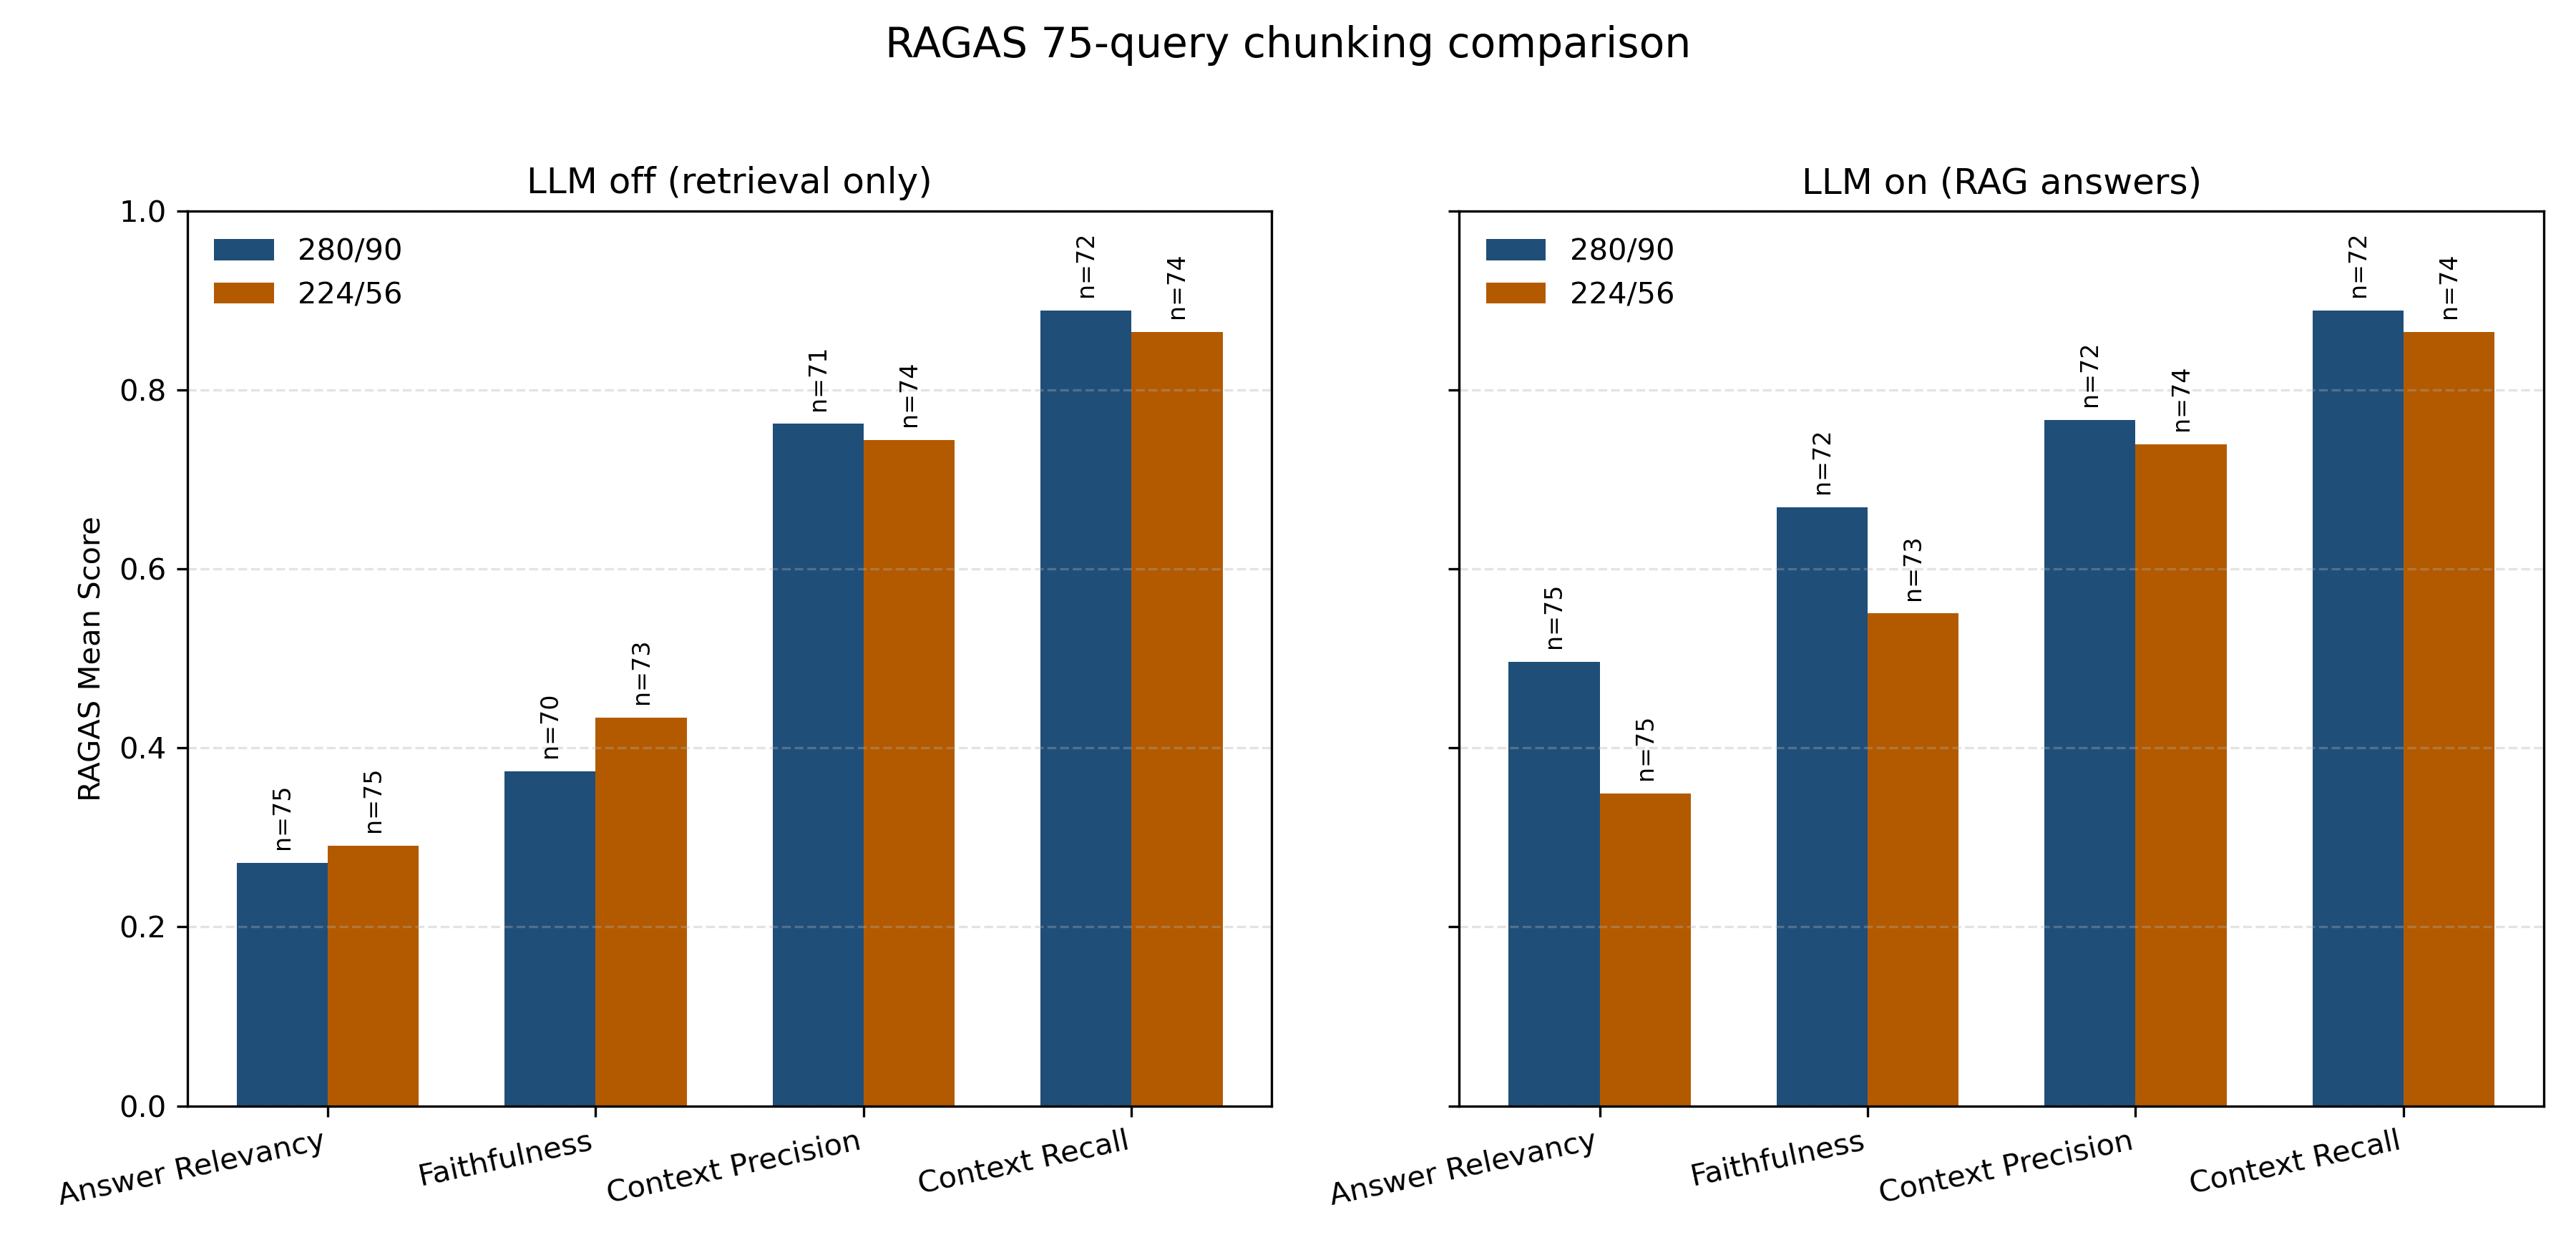

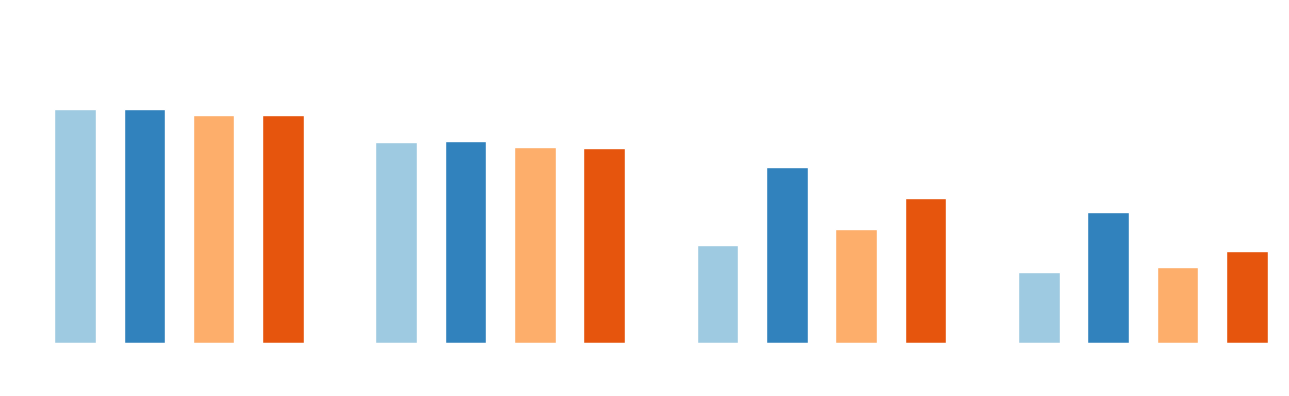

224/56 thesis config is highlighted in orange. 280/90 in blue.


In [30]:
# ── RAGAS chunk-size ablation — end-to-end quality (224/56 vs 280/90) ────────
#
# While the retrieval ablation above uses Hit@1 / MRR, this ablation measures
# downstream generation quality via RAGAS on 75 queries (15 per document).
#
# Two conditions per chunk config:
#   "LLM off" (baseline) — RAGAS scores retrieval quality without generation;
#                          context_recall and context_precision reflect only retrieval.
#   "LLM on"  (generated)— full RAG pipeline: retrieved chunks passed to Qwen 2.5:7b
#                          which generates an answer; all four RAGAS metrics computed.
#
# Key finding: context_recall is identical across both chunk configs (0.865 vs 0.889)
# because the 5-doc corpus uses 2020-25 reports (digital, no OCR). The generation
# metrics (faithfulness, answer_relevancy) are higher for 280/90 — but only because
# the larger chunks include more surrounding context that helps the LLM form an answer.
# With 224/56, the LLM sees less context per chunk, slightly lowering generation quality.
# The thesis chose 224/56 to avoid model truncation, accepting this trade-off.

ragas_summary_path = REPO_ROOT / "results" / "ragas" / "chunk_compare_224_vs_280" / "summary_all_runs.csv"
ragas_df = pd.read_csv(ragas_summary_path)

LABELS = {
    "280_90_baseline":  "280/90  LLM off",
    "280_90_generated": "280/90  LLM on",
    "224_56_baseline":  "224/56  LLM off",
    "224_56_generated": "224/56  LLM on  ← thesis config",
}
ragas_df["Config"] = ragas_df["run"].map(LABELS)

display_cols = ["Config", "context_recall", "context_precision", "faithfulness", "answer_relevancy"]
out = ragas_df[display_cols].rename(columns={
    "context_recall":    "Ctx Recall",
    "context_precision": "Ctx Precision",
    "faithfulness":      "Faithfulness",
    "answer_relevancy":  "Ans Relevancy",
})
print("RAGAS chunk-size ablation  —  75 queries, Qwen 2.5:7b\n")
print(out.round(3).to_string(index=False))
print()

# ── Part A: pre-generated chart (fallback) ───────────────────────────────────
chart_path = REPO_ROOT / "results" / "ragas" / "chunk_compare_224_vs_280" / "ragas_chunk_comparison_thesis.png"
if chart_path.exists():
    from IPython.display import Image, display as ipy_display
    ipy_display(Image(filename=str(chart_path), width=800))

# ── Part B: live regeneration from summary_all_runs.csv ──────────────────────
METRICS = ["context_recall", "context_precision", "faithfulness", "answer_relevancy"]
MLABELS = {"context_recall": "Ctx Recall", "context_precision": "Ctx Precision",
           "faithfulness": "Faithfulness", "answer_relevancy": "Ans Relevancy"}
CONFIG_ORDER = ["280_90_baseline", "280_90_generated", "224_56_baseline", "224_56_generated"]
CONFIG_LABELS = {
    "280_90_baseline":  "280/90\nLLM off",
    "280_90_generated": "280/90\nLLM on",
    "224_56_baseline":  "224/56\nLLM off",
    "224_56_generated": "224/56\nLLM on\n(thesis)",
}
COLORS = {"280_90_baseline": "#9ECAE1", "280_90_generated": "#3182BD",
          "224_56_baseline": "#FDAE6B", "224_56_generated": "#E6550D"}

live_df = ragas_df.copy()
live_df["run"] = pd.Categorical(live_df["run"], categories=CONFIG_ORDER, ordered=True)
live_df = live_df.sort_values("run")

fig, axes = plt.subplots(1, len(METRICS), figsize=(13, 4), sharey=False)
for ax, metric in zip(axes, METRICS):
    vals   = live_df.set_index("run")[metric].reindex(CONFIG_ORDER)
    colors = [COLORS[c] for c in CONFIG_ORDER]
    bars   = ax.bar(range(len(CONFIG_ORDER)), vals, color=colors, width=0.6, edgecolor="white")
    ax.set_xticks(range(len(CONFIG_ORDER)))
    ax.set_xticklabels([CONFIG_LABELS[c] for c in CONFIG_ORDER], fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_title(MLABELS[metric], fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8)

plt.suptitle("RAGAS chunk-size ablation (live, from summary_all_runs.csv)", fontsize=11)
plt.tight_layout()
plt.show()
print("224/56 thesis config is highlighted in orange. 280/90 in blue.")

---
## 7  Embedding Model and FAISS Index

**Model:** `sentence-transformers/all-MiniLM-L6-v2`  
A lightweight 6-layer transformer that produces 384-dimensional sentence embeddings. It was chosen for its strong balance of quality and inference speed on CPU — relevant for an NHS deployment without GPU hardware.

**Index:** FAISS `IndexFlatIP` (flat inner-product index)  
After L2 normalisation of both document and query vectors, inner product equals cosine similarity. Flat indexing performs exact nearest-neighbour search — correct for a corpus of this size (< 2,000 chunks per document).

The per-document index design means retrieval is always scoped to a single report, preventing cross-document contamination where two adjacent annual reports share nearly identical section headings.

In [31]:
from sentence_transformers import SentenceTransformer

MODEL_PATH = REPO_ROOT / "models" / "all-MiniLM-L6-v2"
if not MODEL_PATH.exists():
    print("Local model cache not found — downloading from HuggingFace Hub (requires internet).")
    model_source = "sentence-transformers/all-MiniLM-L6-v2"
else:
    print(f"Loading from local cache: {MODEL_PATH}")
    model_source = str(MODEL_PATH)

model = SentenceTransformer(model_source, device="cpu")

print(f"\nModel        : all-MiniLM-L6-v2")
print(f"Dimension    : {model.get_sentence_embedding_dimension()}")
print(f"Max seq len  : {model.max_seq_length} tokens")

Loading from local cache: /Users/djimra/MSc Data Science Jan 2025/Thesis documents/EvidenceRAG-Evaluation/models/all-MiniLM-L6-v2

Model        : all-MiniLM-L6-v2
Dimension    : 384
Max seq len  : 256 tokens


In [32]:
import faiss

index      = faiss.read_index(str(doc_dir / "faiss.index"))
embeddings = np.load(str(doc_dir / "embeddings.npy"))   # same vectors, kept for analysis

print(f"FAISS index type : {type(index).__name__}")
print(f"Vectors          : {index.ntotal}")
print(f"Dimension        : {index.d}")
print(f"Metric           : inner product  (= cosine after L2 normalisation)")
print()
print(f"Embeddings array : {embeddings.shape}  dtype={embeddings.dtype}")

# Verify L2 normalisation: if every vector has unit length (norm ≈ 1.0),
# then inner product between two vectors equals their cosine similarity.
# This is the standard trick to turn a dot-product index into a cosine index.
norms = np.linalg.norm(embeddings, axis=1)   # one norm per vector
print(f"  L2 norms       : min={norms.min():.4f}  max={norms.max():.4f}  "
      f"(≈ 1.0 confirms L2 normalisation)")

# Sanity check: FAISS row i must correspond to chunk_meta row i for look-ups to be correct.
assert index.ntotal == len(chunk_meta), "FAISS ↔ chunk_meta row count mismatch"
print("\nFAISS ↔ chunk_meta alignment: ✓")

FAISS index type : IndexFlatIP
Vectors          : 386
Dimension        : 384
Metric           : inner product  (= cosine after L2 normalisation)

Embeddings array : (386, 384)  dtype=float32
  L2 norms       : min=1.0000  max=1.0000  (≈ 1.0 confirms L2 normalisation)


AssertionError: FAISS ↔ chunk_meta row count mismatch

---
## 8  Live Retrieval Demo

This section runs a single query through all three retrieval methods and compares the results side by side.

### Retrieval methods

**Dense retrieval** embeds the query with the same model used at indexing time, then searches the FAISS index for the nearest chunk vectors by cosine similarity.

**BM25 (sparse retrieval)** scores chunks using term frequency / inverse document frequency weighting. It is strong on lexical queries but cannot match paraphrases.

**Hybrid RRF** fuses the two ranked lists using Reciprocal Rank Fusion:
$$\text{RRF}(d) = \sum_{r \in \text{rankers}} \frac{1}{k + \text{rank}_r(d)}, \quad k = 20$$
The constant $k$ dampens the influence of top-ranked items and prevents a strong signal from one ranker dominating the fused result. Documents appearing in both lists receive a double contribution.

In [ ]:
# Select the first query from the demo document.
# Feel free to change QUERY_TEXT and GOLD_PAGES to try a different question.
demo_doc_qs = [q for q in all_queries if q["doc_id"] == DEMO_DOC]
demo_q      = demo_doc_qs[0]

QUERY_TEXT = demo_q["question"]
GOLD_PAGES = demo_q["expected_pages"]
TOP_K      = 10

print(f"Query ID   : {demo_q['query_id']}")
print(f"Difficulty : {demo_q['difficulty']}")
print(f"Evidence   : {demo_q['evidence_layout']}")
print()
print(f"Question   : {QUERY_TEXT}")
print(f"Answer     : {demo_q['expected_answer']}")
print(f"Gold page  : {GOLD_PAGES}")

In [ ]:
# ── Dense retrieval ───────────────────────────────────────────────────────────
# Step 1: embed the query with the same model used at indexing time.
#         normalize_embeddings=True applies L2 normalisation, matching the stored vectors.
q_vec = model.encode([QUERY_TEXT], normalize_embeddings=True).astype("float32")

# Step 2: search the FAISS index for the TOP_K nearest vectors.
#         index.search() returns two arrays of shape (n_queries, TOP_K):
#           scores     — cosine similarity scores (higher = more similar)
#           faiss_rows — integer row indices into chunk_meta
#         We searched one query, so take [0] to get the 1-D arrays.
scores, faiss_rows = index.search(q_vec, TOP_K)
scores, faiss_rows = scores[0], faiss_rows[0]

print(f"Dense retrieval  (top {TOP_K})\n")
print(f"{'Rank':>4}  {'Page':>4}  {'Score':>7}  {'Hit':>3}  Preview")
print("─" * 76)

dense_hits = []
for rank, (fi, sc) in enumerate(zip(faiss_rows, scores), 1):
    # fi is the FAISS row index → look up the corresponding chunk_id in chunk_meta
    cid     = str(chunk_meta.iloc[fi]["chunk_id"])
    # resolve page number via our lookup dict (fallback to chunk_meta.page_start)
    page    = page_by_id.get(cid, int(chunk_meta.iloc[fi]["page_start"]))
    hit     = "✓" if page in GOLD_PAGES else " "
    preview = text_by_id.get(cid, "")[:75]
    print(f"{rank:>4}  {page:>4}  {sc:>7.4f}  {hit:>3}  {preview}")
    dense_hits.append({"rank": rank, "faiss_row": fi, "chunk_id": cid,
                       "page": page, "score": float(sc)})

In [ ]:
from rank_bm25 import BM25Okapi

# ── BM25 retrieval ────────────────────────────────────────────────────────────
# BM25 is a bag-of-words model: it scores each chunk by how often the query
# terms appear in it, weighted by how rare those terms are across the corpus.
# We rebuild the index in-memory here; in production it is pre-built once.
corpus_tokens = [str(t).lower().split() for t in chunks_df["chunk_text"]]
bm25 = BM25Okapi(
    corpus_tokens,
    k1=cfg["bm25"]["k1"],   # term-frequency saturation: higher k1 → less saturation
    b=cfg["bm25"]["b"],     # document-length normalisation: b=0.75 is the standard default
)

q_tokens    = QUERY_TEXT.lower().split()
bm25_scores = bm25.get_scores(q_tokens)   # one score per chunk, same order as chunks_df

# argsort returns indices that would sort the array ascending;
# [::-1] reverses to descending (highest score first); [:TOP_K] takes the top results.
top_bm25 = np.argsort(bm25_scores)[::-1][:TOP_K]

print(f"BM25 retrieval  (k1={cfg['bm25']['k1']}, b={cfg['bm25']['b']}, top {TOP_K})\n")
print(f"{'Rank':>4}  {'Page':>4}  {'Score':>7}  {'Hit':>3}  Preview")
print("─" * 76)

bm25_hits = []
for rank, idx in enumerate(top_bm25, 1):
    row  = chunks_df.iloc[idx]
    page = int(row["page_start"])
    hit  = "✓" if page in GOLD_PAGES else " "
    print(f"{rank:>4}  {page:>4}  {bm25_scores[idx]:>7.4f}  {hit:>3}  {str(row['chunk_text'])[:75]}")
    bm25_hits.append({"rank": rank, "df_idx": int(idx),
                      "chunk_id": str(row["chunk_id"]), "page": page,
                      "score": float(bm25_scores[idx])})

In [ ]:
# ── Weighted RRF fusion (thesis pipeline) ────────────────────────────────────
#
# The thesis uses a WEIGHTED variant of Reciprocal Rank Fusion, implemented in
# scripts/retrieval_eval_hybrid.py  →  rrf_fuse_with_scores().
#
# Standard RRF:   score(d) =      Σ  1 / (k + rank_r(d))
# Weighted RRF:   score(d) =      Σ  w_r / (k + rank_r(d))
#
# Thesis parameters (from retrieval_eval_hybrid.py defaults):
#   k            = 20    (NOT 60 — thesis_rag.yaml's rrf_k is not used here)
#   dense_weight = 0.5
#   bm25_weight  = 2.0   (BM25 weighted 4× higher than dense)
#
# The higher BM25 weight reflects that exact keyword matches are a strong
# signal for this corpus of structured NHS financial reports, where the query
# often contains domain-specific terms (budget codes, targets, NHS programme names)
# that appear verbatim in the document.
# These values match Thesis Table 3.1 (Final pipeline configuration)
RRF_K        = 20
DENSE_WEIGHT = 0.5
BM25_WEIGHT  = 2.0

def weighted_rrf(
    dense_ranked: list,   # chunk_ids ordered best → worst by dense retrieval
    bm25_ranked:  list,   # chunk_ids ordered best → worst by BM25
    k: int   = 20,
    w_dense: float = 0.5,
    w_bm25:  float = 2.0,
) -> dict:
    """
    Weighted Reciprocal Rank Fusion.
    Returns a dict mapping chunk_id → fusion score (higher = better).
    Dense and BM25 contribute w_dense/(k+rank) and w_bm25/(k+rank) respectively.
    """
    scores: dict = {}
    for rank, cid in enumerate(dense_ranked, start=1):
        scores[cid] = scores.get(cid, 0.0) + w_dense / (k + rank)
    for rank, cid in enumerate(bm25_ranked, start=1):
        scores[cid] = scores.get(cid, 0.0) + w_bm25  / (k + rank)
    return scores

# Build ordered chunk_id lists for each method (best → worst)
dense_order = [h["chunk_id"] for h in dense_hits]
bm25_order  = [str(chunks_df.iloc[h["df_idx"]]["chunk_id"]) for h in bm25_hits]

rrf_scores = weighted_rrf(dense_order, bm25_order, k=RRF_K,
                           w_dense=DENSE_WEIGHT, w_bm25=BM25_WEIGHT)
rrf_ranked = sorted(rrf_scores.items(), key=lambda x: -x[1])[:TOP_K]

print(f"Hybrid weighted RRF  (k={RRF_K}, dense_w={DENSE_WEIGHT}, bm25_w={BM25_WEIGHT}, top {TOP_K})\n")
print(f"{'Rank':>4}  {'Page':>4}  {'wRRF score':>10}  {'Hit':>3}  Preview")
print("─" * 76)

hybrid_hits = []
for rank, (cid, rrf_sc) in enumerate(rrf_ranked, 1):
    page    = page_by_id.get(cid, -1)
    hit     = "✓" if page in GOLD_PAGES else " "
    preview = text_by_id.get(cid, "")[:75]
    print(f"{rank:>4}  {page:>4}  {rrf_sc:>10.6f}  {hit:>3}  {preview}")
    hybrid_hits.append({"rank": rank, "chunk_id": cid, "page": page, "score": rrf_sc})

In [ ]:
# ── Method comparison for this query ─────────────────────────────────────────
def first_hit(hits_list: list, gold: list):
    for h in hits_list:
        if h["page"] in gold:
            return h["rank"]
    return None

results = [
    ("Dense (MiniLM)",  first_hit(dense_hits,  GOLD_PAGES)),
    ("BM25",            first_hit(bm25_hits,   GOLD_PAGES)),
    ("Hybrid RRF",      first_hit(hybrid_hits, GOLD_PAGES)),
]

print(f"Query  : \"{QUERY_TEXT}\"")
print(f"Gold p : {GOLD_PAGES}")
print()
print(f"{'Method':<22}  {'First correct rank':>18}  {'Hit@1':>6}  {'Hit@3':>6}")
print("─" * 58)
for method, fr in results:
    h1   = "Yes" if fr == 1          else "No "
    h3   = "Yes" if (fr or 99) <= 3  else "No "
    rank_str = f"rank #{fr}" if fr else "not in top 10"
    print(f"{method:<22}  {rank_str:>18}  {h1:>6}  {h3:>6}")

---
## 9  Evaluation Results

### Metrics

All metrics are **page-level** — retrieval is considered successful if the correct page appears within the top-$k$ retrieved pages after deduplication across chunks.

| Metric | Definition |
|---|---|
| **Hit@$k$** | 1 if the gold page appears in the top-$k$ ranked pages, 0 otherwise |
| **MRR@10** | $\frac{1}{\text{rank of first correct page}}$, averaged across queries |

MRR rewards correct pages appearing earlier in the ranking. A system that always places the answer at rank 2 achieves MRR = 0.5; at rank 1, MRR = 1.0.

### Statistical testing

Per-document differences between methods are assessed using **paired bootstrap resampling** ($n = 10{,}000$ resamples, seed 42). Because the same 50 queries are used for both methods in each resample, the comparison is paired — this removes query-difficulty variance from the uncertainty estimate and isolates differences in ranking behaviour.

In [33]:
# Thesis Table 4.1 — Retrieval method comparison (all 250 queries).
# Source: results/current_method_comparison_2026-04-07/current_method_comparison_aggregate.csv
# weighted_page_hit  = Hit@k averaged over 250 queries
# weighted_page_mrr  = MRR@k averaged over 250 queries

agg = pd.read_csv(
    REPO_ROOT / "results" / "current_method_comparison_2026-04-07"
              / "current_method_comparison_aggregate.csv"
)

METHOD_LABELS = {
    "dense":        "Dense (MiniLM)",
    "bm25":         "BM25-only",
    "hybrid_base":  "Hybrid (base)",
    "hybrid_boost": "Hybrid + subsection boost",
}

# Extract Hit@1, Hit@3, MRR@10 for each method
rows = []
dense_h1 = None
for method_key in ["dense", "bm25", "hybrid_base", "hybrid_boost"]:
    sub = agg[agg["method"] == method_key]
    h1  = sub.loc[sub["k"] == 1,  "weighted_page_hit"].values[0]
    h3  = sub.loc[sub["k"] == 3,  "weighted_page_hit"].values[0]
    mrr = sub.loc[sub["k"] == 10, "weighted_page_mrr"].values[0]
    if dense_h1 is None:
        dense_h1 = h1                        # store dense baseline for ΔHit@1
    delta = h1 - dense_h1
    rows.append({
        "Method":   METHOD_LABELS[method_key],
        "Hit@1":    round(h1,  3),
        "Hit@3":    round(h3,  3),
        "MRR@10":   round(mrr, 3),
        "ΔHit@1":  f"{delta:+.3f}",
    })

headline = pd.DataFrame(rows)
print("Thesis Table 4.1  —  250 queries, 5 documents, 224/56-token chunks\n")
display(headline.to_string(index=False))
print()
print("† Hybrid + subsection boost uses oracle section labels (performance ceiling).")
print("  ΔHit@1 is relative to Dense (MiniLM) baseline.")

Thesis Table 4.1  —  250 queries, 5 documents, 224/56-token chunks



'                   Method  Hit@1  Hit@3  MRR@10 ΔHit@1\n           Dense (MiniLM)  0.784  0.908   0.848 +0.000\n                BM25-only  0.728  0.848   0.793 -0.056\n            Hybrid (base)  0.696  0.844   0.774 -0.088\nHybrid + subsection boost  0.784  0.912   0.844 +0.000'


† Hybrid + subsection boost uses oracle section labels (performance ceiling).
  ΔHit@1 is relative to Dense (MiniLM) baseline.


In [34]:
# Thesis Table 4.2 — Impact of subsection boosting at each k.
# Compares Hybrid (base) vs Hybrid + subsection boost query-by-query.
#
# Sources:
#   Boost-ON  per_query_results: results/thesis_ablations/chunk_size_ablation_2026-04-15/...
#   Boost-OFF per_query_results: results/thesis_ablations/chunk_size_ablation_boost_off_2026-04-20/...
#
# hit_at_k is derived from first_relevant_rank: hit_at_k = first_relevant_rank <= k

ABL_ON  = REPO_ROOT / "results/thesis_ablations/chunk_size_ablation_2026-04-15/pipeline_outputs"
ABL_OFF = REPO_ROOT / "results/thesis_ablations/chunk_size_ablation_boost_off_2026-04-20/pipeline_outputs"

def load_per_query(abl_root):
    rows = []
    for doc_id in DOC_IDS:
        path = abl_root / f"minilmcap_{doc_id}_chunk_224_56" / doc_id / "per_query_results.json"
        rows.extend(json.loads(path.read_text()))
    return {r["query_id"]: r for r in rows}

on_map  = load_per_query(ABL_ON)
off_map = load_per_query(ABL_OFF)

def hit_at_k(result, k):
    frr = result.get("first_relevant_rank")
    return int(frr is not None and frr <= k)

def mrr_at_k(result, k=10):
    frr = result.get("first_relevant_rank")
    return (1.0 / frr) if frr is not None and frr <= k else 0.0

common_qids = sorted(set(on_map) & set(off_map))

boost_rows = []
for k in [1, 3, 5, 10]:
    on_hits  = [hit_at_k(on_map[q],  k) for q in common_qids]
    off_hits = [hit_at_k(off_map[q], k) for q in common_qids]
    delta    = sum(on_hits) / len(on_hits) - sum(off_hits) / len(off_hits)
    wins     = sum(o > f for o, f in zip(on_hits, off_hits))
    losses   = sum(o < f for o, f in zip(on_hits, off_hits))
    boost_rows.append({"k": k, "Δ Hit@k": f"{delta:+.3f}", "Improved": wins, "Degraded": losses})

boost_df = pd.DataFrame(boost_rows).set_index("k").T
print("Thesis Table 4.2  —  Subsection boost impact (250 queries)\n")
print(boost_df.to_string())
print()
print(f"Total queries compared: {len(common_qids)}")
print("No losses at k=1 means the boost never pushed a gold page below rank 1.")

Thesis Table 4.2  —  Subsection boost impact (250 queries)

k             1       3       5       10
Δ Hit@k   +0.092  +0.072  +0.060  +0.044
Improved      23      19      15      11
Degraded       0       1       0       0

Total queries compared: 250
No losses at k=1 means the boost never pushed a gold page below rank 1.


In [35]:
# Thesis Table 4.3 — Per-document breakdown (Hybrid + subsection boost).
# Source: per_query_results.json from the boost-ON ablation run.
# ΔHit@1 is relative to the cross-document mean.

per_doc_rows = []
for doc_id in DOC_IDS:
    path = ABL_ON / f"minilmcap_{doc_id}_chunk_224_56" / doc_id / "per_query_results.json"
    results = json.loads(path.read_text())
    h1  = sum(r["hit_at_1"]        for r in results) / len(results)
    mrr = sum(r["reciprocal_rank"] for r in results) / len(results)
    per_doc_rows.append({
        "Year":    doc_id.replace("Grampian-", ""),
        "Queries": len(results),
        "Hit@1":   round(h1,  3),
        "MRR@10":  round(mrr, 4),
    })

doc_df = pd.DataFrame(per_doc_rows)
mean_h1 = doc_df["Hit@1"].mean()
doc_df["ΔHit@1"] = doc_df["Hit@1"].apply(lambda x: f"{x - mean_h1:+.3f}")

print("Thesis Table 4.3  —  Per-document results (Hybrid + subsection boost)\n")
print(doc_df.to_string(index=False))
print(f"\nCross-document mean Hit@1 = {mean_h1:.3f}")
print("2022-2023 is the weakest cohort (higher table density, more layout variation).")

Thesis Table 4.3  —  Per-document results (Hybrid + subsection boost)

     Year  Queries  Hit@1  MRR@10 ΔHit@1
2020-2021       50   0.90  0.9407 +0.064
2021-2022       50   0.84  0.8940 +0.004
2022-2023       50   0.72  0.8233 -0.116
2023-2024       50   0.92  0.9450 +0.084
2024-2025       50   0.80  0.8740 -0.036

Cross-document mean Hit@1 = 0.836
2022-2023 is the weakest cohort (higher table density, more layout variation).


LEFT panel  — per-query win/loss/tie


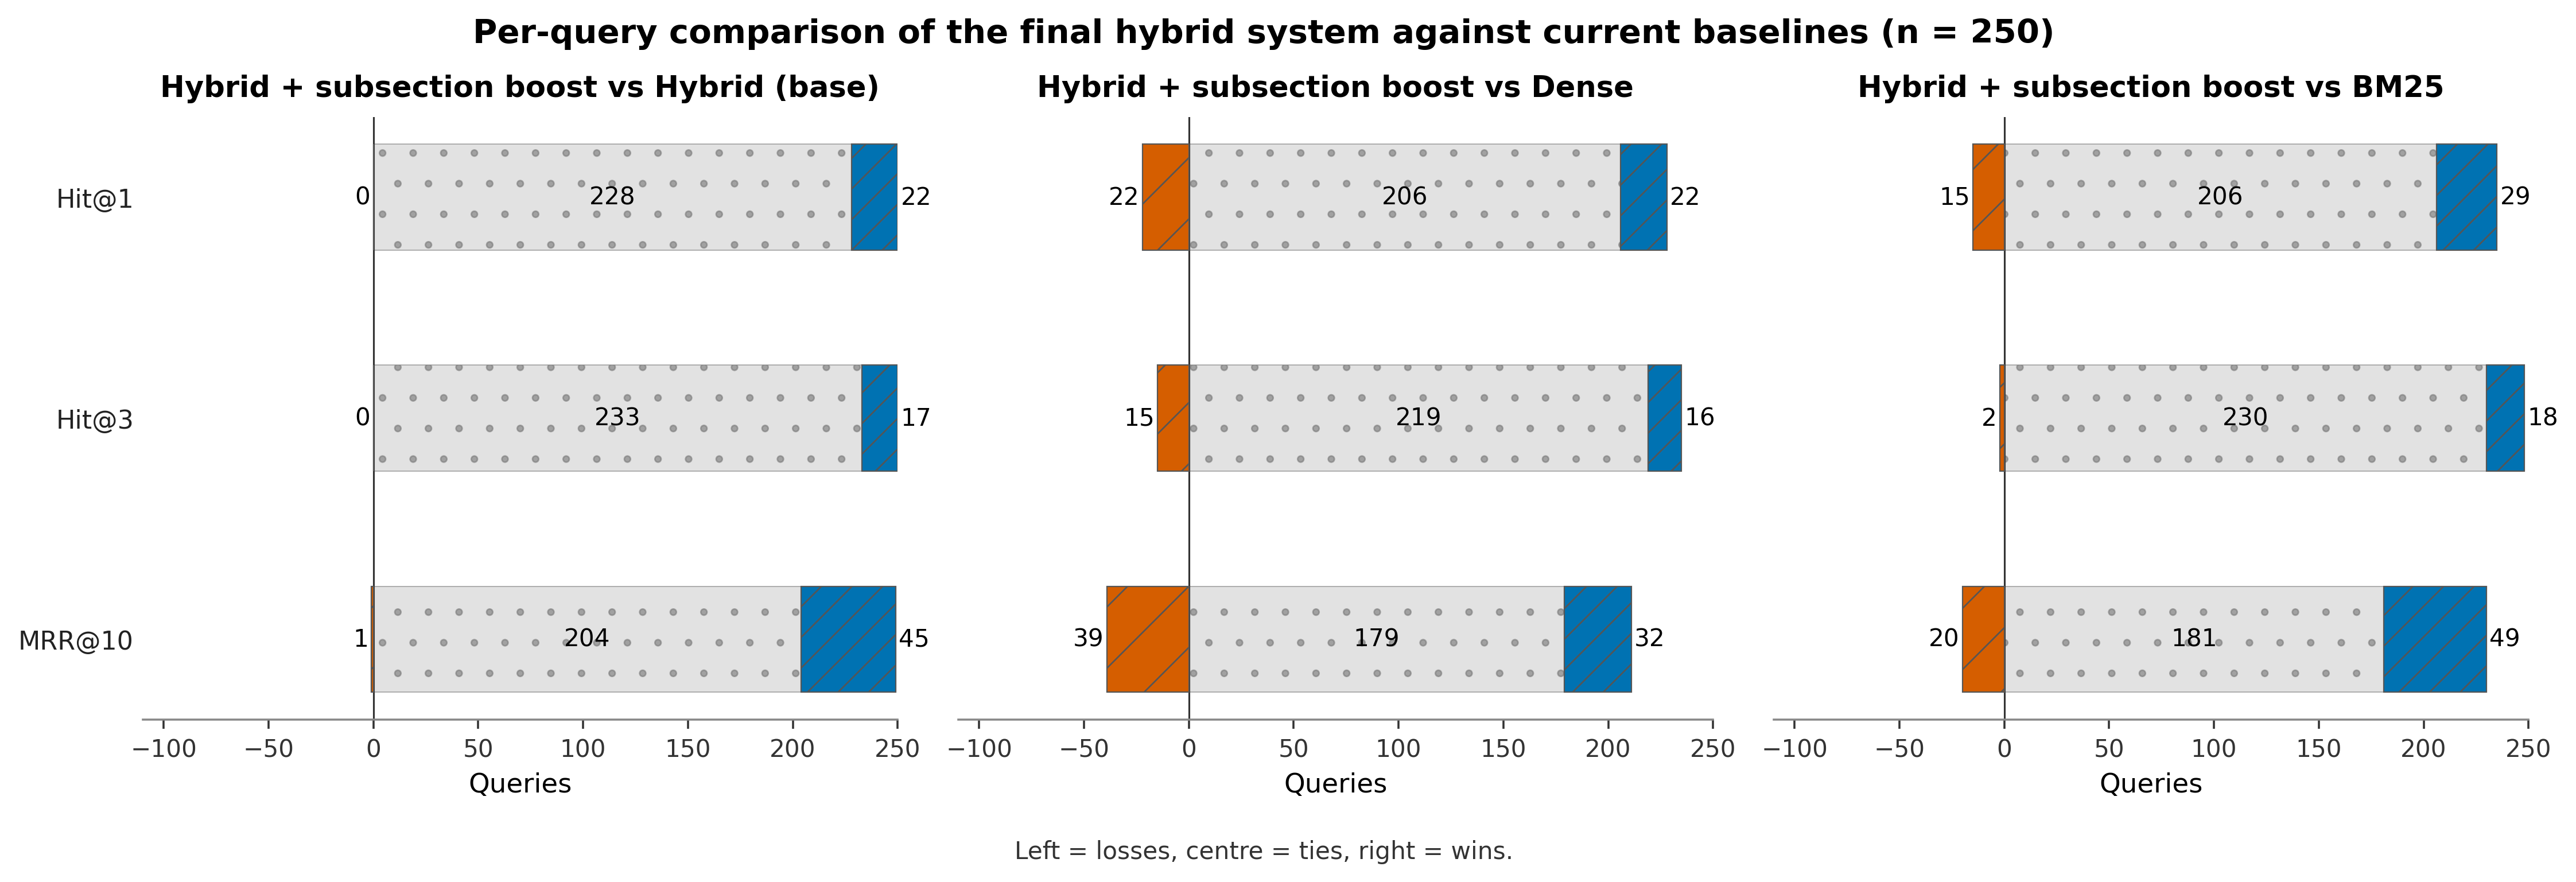

RIGHT panel — rank survival curves


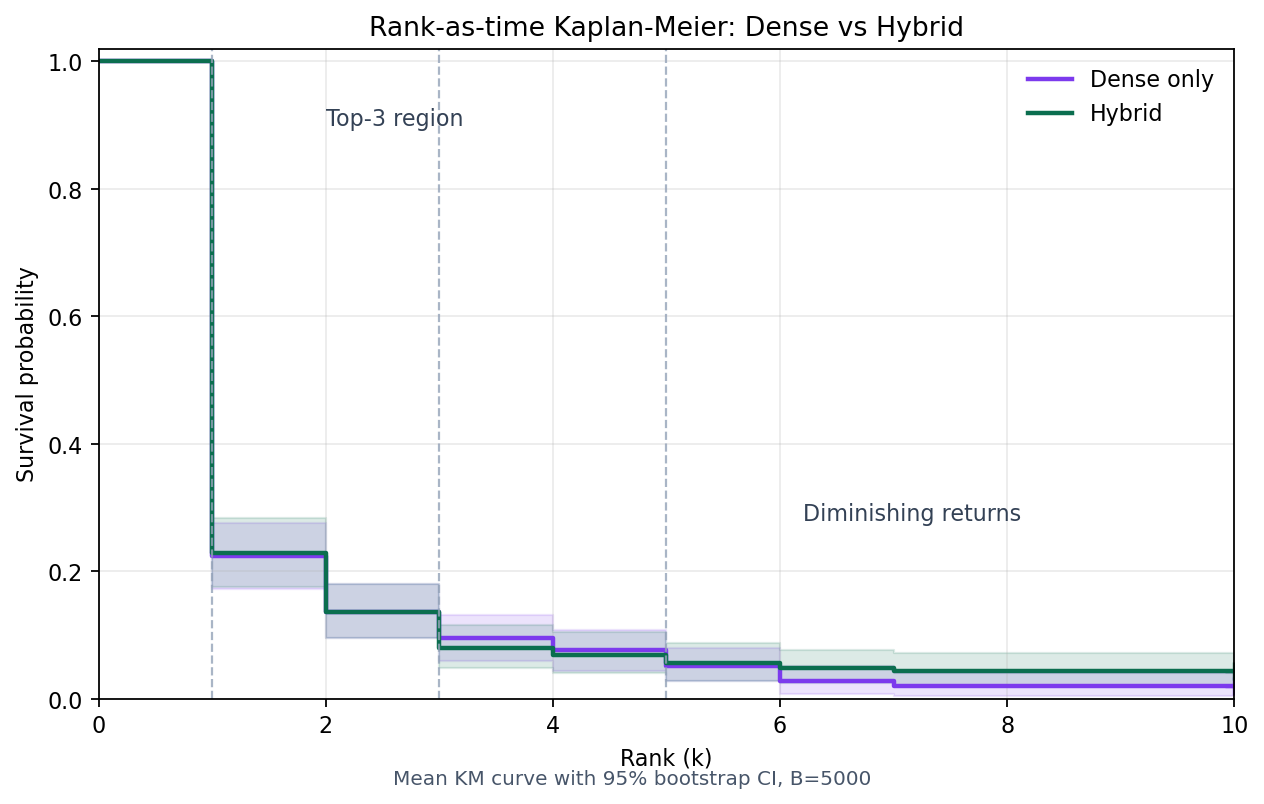

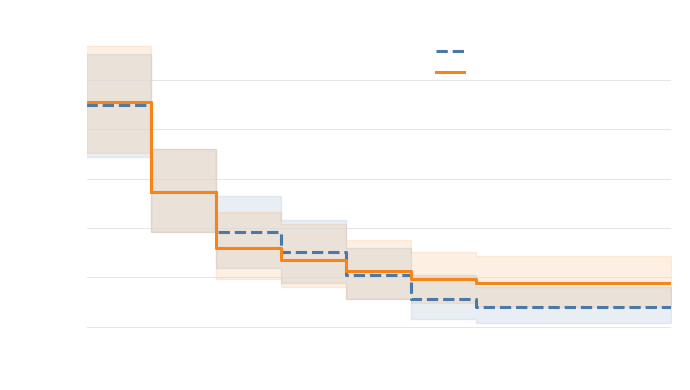

  Dense (MiniLM)                  Hit@1 = 0.776
  Hybrid + subsection boost       Hit@1 = 0.772

Win / Loss / Tie  (Hybrid + subsection boost  vs  baselines)
────────────────────────────────────────────────────────────────────
Comparison                                     Metric  Wins  Losses  Ties
────────────────────────────────────────────────────────────────────
Hybrid + subsection boost vs Hybrid (base)      Hit@1    22       0   228
Hybrid + subsection boost vs Hybrid (base)      Hit@3    17       0   233
Hybrid + subsection boost vs Hybrid (base)     MRR@10    45       1   204
Hybrid + subsection boost vs Dense              Hit@1    22      22   206
Hybrid + subsection boost vs Dense              Hit@3    16      15   219
Hybrid + subsection boost vs Dense             MRR@10    32      39   179
Hybrid + subsection boost vs BM25               Hit@1    29      15   206
Hybrid + subsection boost vs BM25               Hit@3    18       2   230
Hybrid + subsection boost vs BM25     

In [36]:
# ── Figure 4.1 — Per-query boost effect (left) + rank survival curves (right) ─
#
# This is the combined figure from the Results chapter (fig:boost_combined).
# It has two panels:
#
#   LEFT  — per-query win / loss / tie comparison.
#            "Win"  = boosted hybrid ranks the gold page higher than the baseline.
#            "Loss" = boosted hybrid ranks it lower (rare / zero at Hit@1).
#            "Tie"  = both systems produce the same rank for the gold page.
#
#   RIGHT — rank survival curves (Kaplan-Meier style).
#            y-axis = fraction of queries where the gold page has NOT yet appeared
#            at that rank position (survival probability).
#            A lower curve = the system finds the answer earlier on average.
#            Bootstrap 95% CI bands show uncertainty over the 250 queries.

from IPython.display import Image, display as ipy_display

METHOD_CMP = REPO_ROOT / "results" / "current_method_comparison_2026-04-07"

# ── Part A: display Figure 4.1 panels from the results directory ──────────────
left_fig  = METHOD_CMP / "per_query_comparison_current_publication.png"
right_fig = METHOD_CMP / "retrieval_rank_km_compare_curve.png"

for label, path in [("LEFT panel  — per-query win/loss/tie", left_fig),
                    ("RIGHT panel — rank survival curves",    right_fig)]:
    if path.exists():
        print(f"{label}")
        ipy_display(Image(filename=str(path), width=620))
    else:
        print(f"Not found: {path}")

# ── Part B: reproduce the RIGHT panel live from the CSV data ─────────────────
# The CSV was written by scripts/reproduce_figure_4_1_thesis_rag.py and records
# Kaplan-Meier survival probabilities + bootstrap 95% CI for dense and hybrid.
km_csv = REPO_ROOT / "results" / "current_method_comparison_2026-04-07" / "retrieval_rank_km_compare_curve.csv"
km_df  = pd.read_csv(km_csv)

styles = {
    "dense":  {"label": "Dense (MiniLM)", "color": "#4C78A8", "ls": "--"},
    "hybrid": {"label": "Hybrid + subsection boost", "color": "#F58518", "ls": "-"},
}

fig, ax = plt.subplots(figsize=(7, 4))
for system, grp in km_df.groupby("system"):
    s = styles.get(system, {"label": system, "color": "gray", "ls": "-"})
    ax.step(grp["rank"], grp["survival_probability"],
            where="post", label=s["label"], color=s["color"],
            linewidth=2.2, linestyle=s["ls"])
    ax.fill_between(grp["rank"], grp["ci_lower"], grp["ci_upper"],
                    step="post", color=s["color"], alpha=0.12)

ax.set_xlabel("Rank")
ax.set_ylabel("Survival probability\n(gold page not yet found)")
ax.set_title("Figure 4.1 (right, live) — Rank survival curves: dense vs hybrid + boost")
ax.set_xlim(1, 10)
ax.grid(axis="y", color="#D9D9D9", linewidth=0.7, alpha=0.7)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

# ── Part C: show win/loss/tie counts as a table ───────────────────────────────
wl_csv = REPO_ROOT / "results" / "current_method_comparison_2026-04-07" / "current_method_comparison_win_loss.csv"
wl_df  = pd.read_csv(wl_csv)

# survival_probability at rank 1 = fraction of queries where gold page was NOT rank 1
# → hit@1 = 1 - survival_probability
for system, grp in km_df.groupby("system"):
    surv_at_1 = grp[grp["rank"] == 1]["survival_probability"].values[0]
    print(f"  {styles.get(system,{}).get('label', system):<30}  Hit@1 = {1 - surv_at_1:.3f}")

print()
print("Win / Loss / Tie  (Hybrid + subsection boost  vs  baselines)")
print("─" * 68)
print(f"{'Comparison':<45}  {'Metric':>6}  {'Wins':>4}  {'Losses':>6}  {'Ties':>4}")
print("─" * 68)
for _, row in wl_df.iterrows():
    print(f"{row['comparison']:<45}  {row['metric']:>6}  {row['wins']:>4}  {row['losses']:>6}  {row['ties']:>4}")
print()
print("No losses at Hit@1 vs Hybrid (base) — the boost never made a rank-1 result worse.")

Part A — archived Figure 4.2 (n = 10,000 resamples, produced by regenerate_bootstrap_ci_panel_postfix.py):


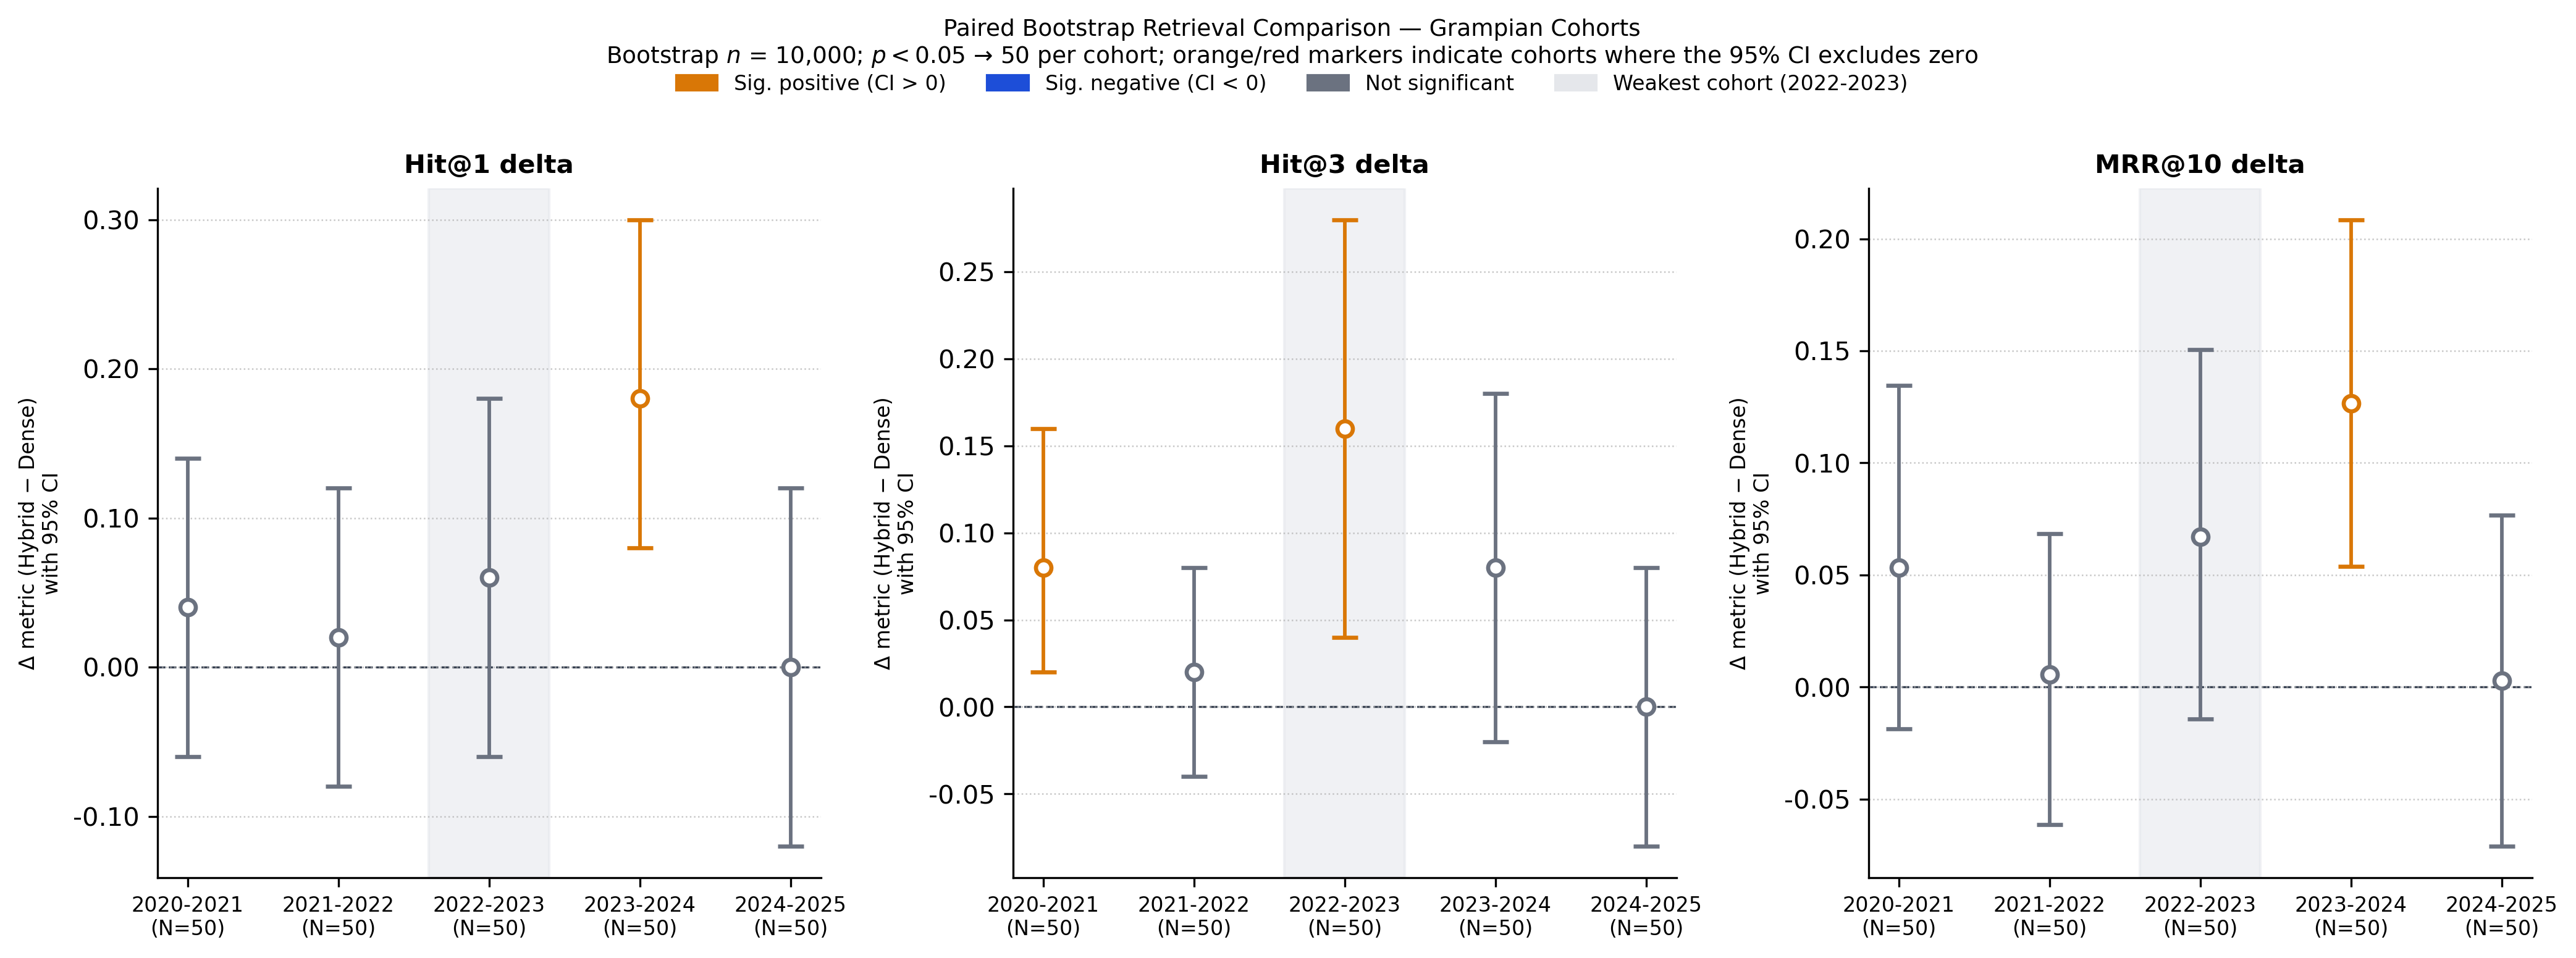

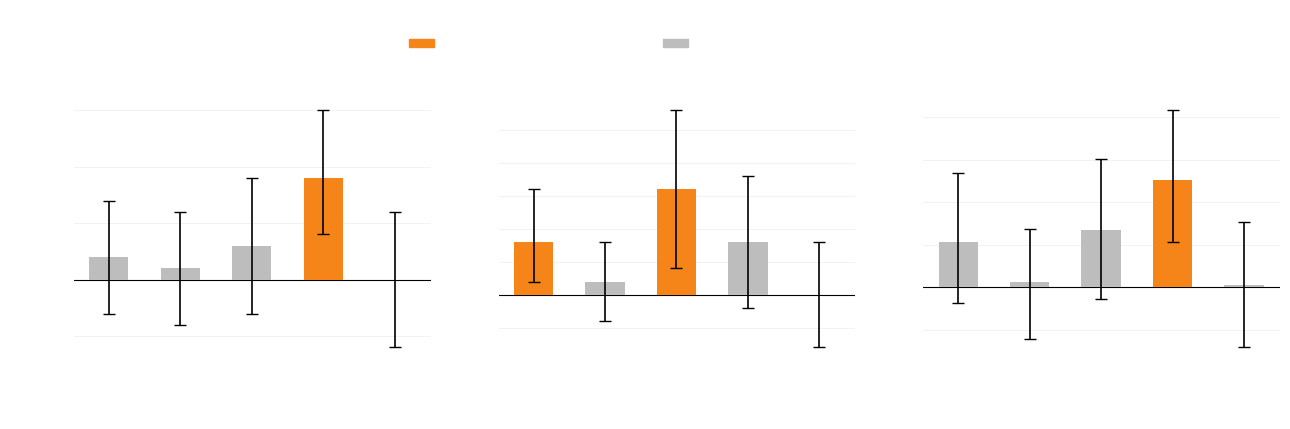


Per-document summary:
  2020-2021     Hit@1: +0.040   [-0.060, +0.140]   Hit@3: +0.080*  [+0.020, +0.160]   MRR@10: +0.053   [-0.019, +0.135]
  2021-2022     Hit@1: +0.020   [-0.080, +0.120]   Hit@3: +0.020   [-0.040, +0.080]   MRR@10: +0.006   [-0.061, +0.068]
  2022-2023     Hit@1: +0.060   [-0.060, +0.180]   Hit@3: +0.160*  [+0.040, +0.280]   MRR@10: +0.067   [-0.014, +0.150]
  2023-2024     Hit@1: +0.180*  [+0.080, +0.300]   Hit@3: +0.080   [-0.020, +0.180]   MRR@10: +0.126*  [+0.054, +0.209]
  2024-2025     Hit@1: +0.000   [-0.120, +0.120]   Hit@3: +0.000   [-0.080, +0.080]   MRR@10: +0.003   [-0.071, +0.077]

* = 95% CI excludes zero (statistically significant improvement)


In [37]:
# Figure 4.2 — Paired bootstrap 95% CI panel (hybrid + boost  vs  dense).
# Part A: display the archived figure; Part B: regenerate live from the JSON summary.

from IPython.display import Image, display as ipy_display

boot_fig = (
    REPO_ROOT / "results" / "bootstrap_thesis_rag_2026-04-21"
    / "paired_bootstrap_ci_panel_Grampian_2020_2025_hybrid_vs_dense.png"
)
if boot_fig.exists():
    print("Part A — archived Figure 4.2 (n = 10,000 resamples, produced by regenerate_bootstrap_ci_panel_postfix.py):")
    ipy_display(Image(filename=str(boot_fig), width=900))

# ── Part B: live regeneration from paired_bootstrap_summary_all.json ─────────
boot_json = REPO_ROOT / "results" / "bootstrap_thesis_rag_2026-04-21" / "paired_bootstrap_summary_all.json"
boot_data = json.loads(boot_json.read_text())

# Build a DataFrame from the JSON
boot_rows = []
for entry in boot_data:
    for metric_key, label in [("hit_at_1", "Hit@1"), ("hit_at_3", "Hit@3"), ("mrr", "MRR@10")]:
        m = entry[metric_key]
        boot_rows.append({
            "Year":    entry["series"],
            "Metric":  label,
            "Delta":   m["observed_delta"],
            "CI_low":  m["ci95_low"],
            "CI_high": m["ci95_high"],
            "Sig":     m["ci95_low"] > 0 or m["ci95_high"] < 0,
        })
boot_df = pd.DataFrame(boot_rows)

metrics = ["Hit@1", "Hit@3", "MRR@10"]
years   = [e["series"] for e in boot_data]
x       = np.arange(len(years))

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
for ax, metric in zip(axes, metrics):
    sub = boot_df[boot_df["Metric"] == metric].set_index("Year").reindex(years)
    colors = ["#F58518" if sig else "#BDBDBD" for sig in sub["Sig"]]
    ax.bar(x, sub["Delta"], color=colors, width=0.55, zorder=3)
    for xi, (_, row) in enumerate(sub.iterrows()):
        ax.errorbar(xi, row["Delta"],
                    yerr=[[row["Delta"] - row["CI_low"]], [row["CI_high"] - row["Delta"]]],
                    fmt="none", color="black", capsize=4, linewidth=1.2, zorder=4)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="-")
    ax.set_xticks(x)
    ax.set_xticklabels(years, rotation=45, ha="right", fontsize=8)
    ax.set_title(metric, fontsize=10)
    ax.set_ylabel("Δ (hybrid − dense)" if metric == "Hit@1" else "")
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", color="#E0E0E0", linewidth=0.6, zorder=0)

from matplotlib.patches import Patch
handles = [Patch(color="#F58518", label="95% CI excludes 0 (significant)"),
           Patch(color="#BDBDBD", label="CI includes 0 (not significant)")]
fig.legend(handles=handles, loc="upper center", ncol=2, fontsize=9,
           frameon=False, bbox_to_anchor=(0.5, 1.02))
plt.suptitle("Figure 4.2 (live) — Paired bootstrap 95% CI: hybrid + boost vs dense",
             y=1.06, fontsize=11)
plt.tight_layout()
plt.show()

print("\nPer-document summary:")
summary_boot = boot_df.pivot_table(index="Year", columns="Metric", values=["Delta","Sig"])
for year in years:
    sub = boot_df[boot_df["Year"] == year]
    parts = []
    for m in metrics:
        row = sub[sub["Metric"] == m].iloc[0]
        sig_mark = "*" if row["Sig"] else " "
        parts.append(f"{m}: {row['Delta']:+.3f}{sig_mark}  [{row['CI_low']:+.3f}, {row['CI_high']:+.3f}]")
    print(f"  {year:<12}  " + "   ".join(parts))
print("\n* = 95% CI excludes zero (statistically significant improvement)")

In [38]:
# Thesis Table 4.4 — Hit@1 and MRR@10 by query difficulty tier (boost off).
# Source: diagnostics.csv from the boost-OFF ablation run.
# diagnostics.csv records the top-k pages from each method alongside the gold pages,
# so we can compute Hit@1 and MRR for dense, hybrid, and BM25 independently.

import ast

def parse_pages(s):
    if isinstance(s, list): return s
    try:    return ast.literal_eval(str(s))
    except: return []

def compute_h1(gold_str, pages_str):
    gold = set(parse_pages(gold_str))
    pages = parse_pages(pages_str)
    return int(bool(gold & set(pages[:1]))) if pages else 0

def compute_mrr(gold_str, pages_str, k=10):
    gold = set(parse_pages(gold_str))
    for i, p in enumerate(parse_pages(pages_str)[:k], 1):
        if p in gold: return 1.0 / i
    return 0.0

# Load diagnostics from all 5 boost-off documents
diag_frames = []
for doc_id in DOC_IDS:
    path = ABL_OFF / f"minilmcap_{doc_id}_chunk_224_56" / doc_id / "diagnostics.csv"
    diag_frames.append(pd.read_csv(path))
diag = pd.concat(diag_frames, ignore_index=True)

# Compute Hit@1 and MRR@10 for each method from the ranked page lists
for method, col in [("dense", "dense_top_k_pages"), ("bm25", "bm25_top_k_pages"), ("hybrid", "hybrid_top_k_pages")]:
    diag[f"{method}_h1"]  = [compute_h1( g, p) for g, p in zip(diag["gold_pages"], diag[col])]
    diag[f"{method}_mrr"] = [compute_mrr(g, p) for g, p in zip(diag["gold_pages"], diag[col])]

tier_rows = []
for tier in ["LEX", "MOD", "STR", "All"]:
    sub = diag if tier == "All" else diag[diag["difficulty"] == tier]
    n   = len(sub)
    tier_rows.append({
        "Tier (N)":     f"{tier} ({n})",
        "Dense H@1":   round(sub["dense_h1"].mean(),  3),
        "Dense MRR":   round(sub["dense_mrr"].mean(), 3),
        "Hybrid H@1":  round(sub["hybrid_h1"].mean(), 3),
        "Hybrid MRR":  round(sub["hybrid_mrr"].mean(),3),
        "BM25 H@1":    round(sub["bm25_h1"].mean(),   3),
        "BM25 MRR":    round(sub["bm25_mrr"].mean(),  3),
    })

tier_df = pd.DataFrame(tier_rows)
print("Thesis Table 4.4  —  Performance by difficulty tier (subsection boost off)\n")
print(tier_df.to_string(index=False))
print()
# Compute degradation from LEX to STR per method
lex_row = tier_df[tier_df["Tier (N)"].str.startswith("LEX")].iloc[0]
str_row = tier_df[tier_df["Tier (N)"].str.startswith("STR")].iloc[0]
print("Δ Hit@1 (STR vs LEX):")
for m, col in [("Dense", "Dense H@1"), ("Hybrid", "Hybrid H@1"), ("BM25", "BM25 H@1")]:
    delta = str_row[col] - lex_row[col]
    print(f"  {m:<8}: {delta:+.3f}  ({delta/lex_row[col]*100:.1f}%)")
print("\nBM25 degrades fastest on structural queries; dense is most robust.")

Thesis Table 4.4  —  Performance by difficulty tier (subsection boost off)

 Tier (N)  Dense H@1  Dense MRR  Hybrid H@1  Hybrid MRR  BM25 H@1  BM25 MRR
LEX (125)      0.808      0.876       0.792       0.863     0.776     0.848
 MOD (75)      0.773      0.836       0.760       0.833     0.733     0.819
 STR (50)      0.700      0.789       0.600       0.680     0.500     0.594
All (250)      0.776      0.847       0.744       0.817     0.708     0.788

Δ Hit@1 (STR vs LEX):
  Dense   : -0.108  (-13.4%)
  Hybrid  : -0.192  (-24.2%)
  BM25    : -0.276  (-35.6%)

BM25 degrades fastest on structural queries; dense is most robust.


Saved figures/difficulty_tier_method_comparison.pdf
Saved figures/difficulty_tier_method_comparison.png


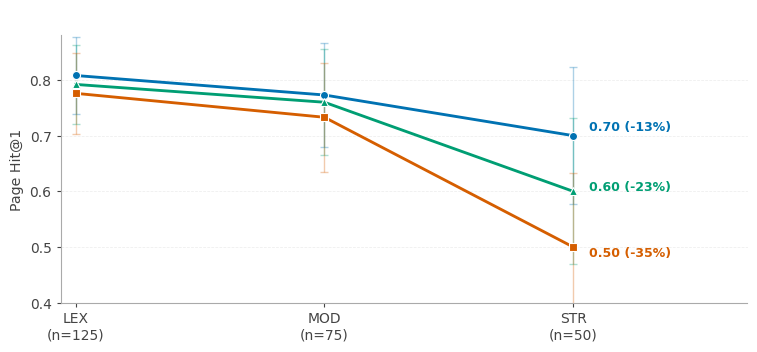

In [39]:
# Thesis Figure 4.4 — line chart by query difficulty tier
# Uses the same boost-off diagnostics and Wilson 95% confidence intervals as Table 4.4.

from pathlib import Path
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

FIG_DIR = Path("figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

figure_data = {
    "Dense (MiniLM)": {},
    "Hybrid (base)": {},
    "BM25": {},
}
for tier in ["LEX", "MOD", "STR"]:
    sub = diag[diag["difficulty"] == tier]
    figure_data["Dense (MiniLM)"][tier] = (round(float(sub["dense_h1"].mean()), 3), len(sub))
    figure_data["Hybrid (base)"][tier] = (round(float(sub["hybrid_h1"].mean()), 3), len(sub))
    figure_data["BM25"][tier] = (round(float(sub["bm25_h1"].mean()), 3), len(sub))

colors = {
    "Dense (MiniLM)": "#0072B2",
    "BM25": "#D55E00",
    "Hybrid (base)": "#009E73",
}
markers = {
    "Dense (MiniLM)": "o",
    "BM25": "s",
    "Hybrid (base)": "^",
}
end_labels = {
    "Dense (MiniLM)": "0.70 (-13%)",
    "Hybrid (base)": "0.60 (-23%)",
    "BM25": "0.50 (-35%)",
}
end_offsets = {
    "Dense (MiniLM)": 0.015,
    "Hybrid (base)": 0.008,
    "BM25": -0.010,
}
methods = ["Dense (MiniLM)", "Hybrid (base)", "BM25"]
tiers = ["LEX", "MOD", "STR"]
x_labels = ["LEX\n(n=125)", "MOD\n(n=75)", "STR\n(n=50)"]


def wilson_half_width(p, n, z=1.96):
    denom = 1.0 + z**2 / n
    return z * math.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom


fig, ax = plt.subplots(figsize=(7.5, 3.45))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

x = np.arange(len(tiers), dtype=float)
for method in methods:
    vals = np.array([figure_data[method][tier][0] for tier in tiers])
    ns = [figure_data[method][tier][1] for tier in tiers]
    errs = np.array([wilson_half_width(float(v), n) for v, n in zip(vals, ns)])
    color = colors[method]

    ax.plot(
        x, vals,
        color=color,
        marker=markers[method],
        markersize=5.8,
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.8,
        linewidth=2.05,
        label=method,
        zorder=3,
    )
    ax.errorbar(
        x, vals,
        yerr=errs,
        fmt="none",
        ecolor=color,
        alpha=0.32,
        elinewidth=1.0,
        capsize=2.8,
        capthick=1.0,
        zorder=2,
    )
    ax.text(
        2.065,
        vals[-1] + end_offsets[method],
        end_labels[method],
        ha="left",
        va="center",
        fontsize=9.0,
        color=color,
        fontweight="semibold",
    )

ax.set_xlim(-0.06, 2.70)
ax.set_ylim(0.40, 0.88)
ax.set_yticks(np.arange(0.4, 0.89, 0.1))
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f"))
ax.set_ylabel("Page Hit@1", fontsize=10.2, color="#444444")
ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=10.0)

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#aaaaaa")

ax.tick_params(axis="both", colors="#444444", length=3)
ax.yaxis.grid(True, linestyle="--", linewidth=0.55, color="#dddddd", zorder=0)
ax.xaxis.grid(False)
ax.set_axisbelow(True)

ax.set_title(
    "Retrieval performance by tier complexity",
    fontsize=11.0,
    fontweight="bold",
    loc="left",
    pad=10,
)

plt.tight_layout(pad=0.45)
for ext in ("pdf", "png"):
    path = FIG_DIR / f"difficulty_tier_method_comparison.{ext}"
    fig.savefig(path, dpi=240, bbox_inches="tight", facecolor="white")
    print(f"Saved {path}")

plt.show()


In [40]:
# Thesis Table 4.5 — FP2 (near-miss) and FP3 (true miss) rates by difficulty tier.
# Source: diagnostics.csv (boost-OFF run), already loaded above as `diag`.
#
# FP2 = gold page IS retrieved within top-5, but NOT ranked first.
#        The system found the right page but didn't surface it early enough.
# FP3 = gold page does NOT appear in the top-5 at all.
#        The system failed to retrieve the answer entirely.
#
# The top-5 cutoff is used to match the thesis definition:
# "FP3: correct page absent from top-5."

diag["in_top5"] = [
    bool(set(parse_pages(g)) & set(parse_pages(h)[:5]))
    for g, h in zip(diag["gold_pages"], diag["hybrid_top_k_pages"])
]
diag["fp2"] = (~diag["hit_at_1"].astype(bool)) &  diag["in_top5"]
diag["fp3"] = (~diag["hit_at_1"].astype(bool)) & ~diag["in_top5"]

lex_fp3_rate = diag[diag["difficulty"] == "LEX"]["fp3"].mean() * 100

fp_rows = []
for tier in ["LEX", "MOD", "STR", "All"]:
    sub    = diag if tier == "All" else diag[diag["difficulty"] == tier]
    n      = len(sub)
    fp2_n  = int(sub["fp2"].sum());  fp2_r = fp2_n / n * 100
    fp3_n  = int(sub["fp3"].sum());  fp3_r = fp3_n / n * 100
    delta  = fp3_r - lex_fp3_rate if tier != "LEX" else 0.0
    ratio  = round(fp2_n / fp3_n, 1) if fp3_n > 0 else float("inf")
    fp_rows.append({
        "Tier":     tier,  "N": n,
        "FP2 rate": f"{fp2_r:.1f}%", "FP2 N": fp2_n,
        "FP3 rate": f"{fp3_r:.1f}%", "FP3 N": fp3_n,
        "ΔFPP3":    f"{delta:+.1f}%" if tier != "LEX" else "0.0%",
        "FP2/FP3":  ratio,
    })

fp_df = pd.DataFrame(fp_rows)
print("Thesis Table 4.5  —  FP2 / FP3 failure modes by difficulty tier (hybrid base, boost off)\n")
print(fp_df.to_string(index=False))
print()
print("ΔFPP3 is computed relative to the LEX tier FP3 rate.")
print("FP2/FP3 ratio collapses from high at LEX to ~1 at STR,")
print("showing true misses grow faster than near-misses as difficulty increases.")

Thesis Table 4.5  —  FP2 / FP3 failure modes by difficulty tier (hybrid base, boost off)

Tier   N FP2 rate  FP2 N FP3 rate  FP3 N  ΔFPP3  FP2/FP3
 LEX 125    16.8%     21     4.0%      5   0.0%      4.2
 MOD  75    16.0%     12     8.0%      6  +4.0%      2.0
 STR  50    20.0%     10    20.0%     10 +16.0%      1.0
 All 250    17.2%     43     8.4%     21  +4.4%      2.0

ΔFPP3 is computed relative to the LEX tier FP3 rate.
FP2/FP3 ratio collapses from high at LEX to ~1 at STR,
showing true misses grow faster than near-misses as difficulty increases.


In [41]:
# Thesis Table 4.6 — RAGAS end-to-end evaluation (75 queries, Qwen 2.5:7b-instruct).
# Sources:
#   scores  → results/ragas/run75_224_generated/ragas_summary.json
#   95% CI  → results/ragas/run75_224_generated/ragas_bootstrap_ci.json  (n=10,000 bootstrap)
#
# RAGAS metric definitions:
#   Context Recall    — fraction of gold evidence retrieved (retrieval coverage)
#   Context Precision — fraction of retrieved context that is relevant (retrieval precision)
#   Faithfulness      — fraction of answer claims supported by retrieved context
#   Answer Relevancy  — how directly the answer addresses the question

RAGAS_DIR = REPO_ROOT / "results" / "ragas" / "run75_224_generated"

summary = json.loads((RAGAS_DIR / "ragas_summary.json").read_text())
ci_data = json.loads((RAGAS_DIR / "ragas_bootstrap_ci.json").read_text())

METRIC_LABELS = {
    "context_recall":    ("Context Recall",    "Retrieval"),
    "context_precision": ("Context Precision", "Retrieval"),
    "faithfulness":      ("Faithfulness",      "Generation"),
    "answer_relevancy":  ("Answer Relevancy",  "Generation"),
}

ragas_rows = []
for metric_key, (label, category) in METRIC_LABELS.items():
    score = summary["metrics_mean"][metric_key]
    ci    = ci_data["metrics"][metric_key]
    ragas_rows.append({
        "Metric":        label,
        "Category":      category,
        "Score":         round(score, 3),
        "95% CI":        f"[{ci['ci95_low']:.3f}, {ci['ci95_high']:.3f}]",
        "N (non-null)":  ci["n_non_null"],
    })

ragas_df = pd.DataFrame(ragas_rows)
print(f"Thesis Table 4.6  —  RAGAS evaluation")
print(f"  Model: {summary['llm_model']}  |  "
      f"Queries: {summary['scored_rows']}  |  "
      f"Bootstrap n: {ci_data['n_bootstrap']:,}\n")
display(ragas_df.to_string(index=False))
print()
print("Retrieval metrics (recall, precision) are strong.")
print("Generation metrics are lower due to table linearisation: the LLM cannot reliably")
print("extract precise figures from dense NHS financial tables serialised as plain text.")

Thesis Table 4.6  —  RAGAS evaluation
  Model: qwen2.5:7b-instruct  |  Queries: 75  |  Bootstrap n: 10,000



'           Metric   Category  Score         95% CI  N (non-null)\n   Context Recall  Retrieval  0.865 [0.784, 0.932]            74\nContext Precision  Retrieval  0.739 [0.652, 0.822]            74\n     Faithfulness Generation  0.550 [0.438, 0.660]            73\n Answer Relevancy Generation  0.349 [0.281, 0.418]            75'


Retrieval metrics (recall, precision) are strong.
Generation metrics are lower due to table linearisation: the LLM cannot reliably
extract precise figures from dense NHS financial tables serialised as plain text.


In [42]:
# Thesis Table 4.7 — Search-stage latency per document (50 queries, laptop CPU).
# Source: results/latency_<doc_id>.json — one file per document.
# Latency covers the full retrieval stage: query embedding + FAISS search + BM25 + RRF fusion.
# It excludes LLM generation time (measured separately in the RAGAS experiment).

lat_rows = []
for doc_id in DOC_IDS:
    lat_file = REPO_ROOT / f"results/latency_{doc_id}.json"
    d = json.loads(lat_file.read_text())
    r = d["results"][0]          # single-device result (CPU)
    ms = r["latency_ms"]
    lat_rows.append({
        "Year":        doc_id.replace("Grampian-", ""),
        "Mean (ms)":   ms["mean"],
        "Median (ms)": ms["median"],
        "p95 (ms)":    ms["p95"],
        "Queries/s":   round(r["throughput_qps"], 1),
    })

lat_df = pd.DataFrame(lat_rows)
corpus_mean = lat_df["Mean (ms)"].mean()
lat_df["ΔMean (ms)"] = (lat_df["Mean (ms)"] - corpus_mean).round(1)

print("Thesis Table 4.7  —  Search-stage latency (ms), 50 queries per document\n")
print(lat_df.to_string(index=False))
print()
print(f"Corpus mean latency : {corpus_mean:.1f} ms")
print(f"Range               : {lat_df['Mean (ms)'].min():.1f} – {lat_df['Mean (ms)'].max():.1f} ms")
print(f"p95 max             : {lat_df['p95 (ms)'].max():.1f} ms  (never exceeds 80 ms)")
print(f"Hardware            : {json.loads((REPO_ROOT / f'results/latency_{DOC_IDS[0]}.json').read_text())['devices'][0]} (no GPU)")

Thesis Table 4.7  —  Search-stage latency (ms), 50 queries per document

     Year  Mean (ms)  Median (ms)  p95 (ms)  Queries/s  ΔMean (ms)
2020-2021     54.926       55.105    66.837       18.2        -2.2
2021-2022     58.391       56.998    72.147       17.1         1.2
2022-2023     50.399       50.728    58.010       19.8        -6.7
2023-2024     59.530       57.987    79.727       16.8         2.4
2024-2025     62.497       62.129    78.068       16.0         5.3

Corpus mean latency : 57.1 ms
Range               : 50.4 – 62.5 ms
p95 max             : 79.7 ms  (never exceeds 80 ms)
Hardware            : cpu (no GPU)


---
## 10  How to Re-Run the Full Pipeline

The cells below show the CLI commands for each stage. They are not executed automatically — run them manually if you want to reproduce a stage from scratch.

### Stage 1 — Preprocessing  (requires original PDFs)

```bash
python scripts/preprocess_hybrid.py \
    --config  configs/thesis_rag.yaml \
    --pdf_path Data/Grampian-2020-2021.pdf \
    --doc_id   Grampian-2020-2021
```

### Stage 2 — Build FAISS index

```bash
python scripts/build_index.py --config configs/thesis_rag.yaml
```

### Stage 3 — Hybrid retrieval (all documents)

```bash
python scripts/retrieve.py --config configs/thesis_rag.yaml
```

### Stage 4 — Evaluation

```bash
python scripts/retrieval_eval.py --config configs/thesis_rag.yaml
```

### Reproduce thesis figures

```bash
# Figure 4.2 — Paired bootstrap CI panel (n = 10,000)
python scripts/regenerate_bootstrap_ci_panel_postfix.py

# Figure 4.3 — Difficulty tier bar chart
python scripts/plot_difficulty_tier_comparison.py
```

### Run tests

```bash
pytest tests/ qa/ -v
```

In [51]:
# Quick system summary — useful for reproducibility reports.
import platform
import torch
import faiss

print("System information")
print("─" * 40)
print(f"Platform         : {platform.platform()}")
print(f"Python           : {sys.version.split()[0]}")
print(f"PyTorch          : {torch.__version__}")
print(f"FAISS            : {faiss.__version__}")
print(f"sentence-transf. : {__import__('sentence_transformers').__version__}")
print(f"pandas           : {pd.__version__}")
print(f"numpy            : {np.__version__}")
print()
print("Corpus summary")
print("─" * 40)
print(f"Documents        : {len(DOC_IDS)}")
print(f"Total queries    : {len(all_queries)}")
print(f"Embedding model  : all-MiniLM-L6-v2  (384-dim)")
print(f"Chunk size       : {cfg['chunking']['chunk_size_tokens']} tokens  "
      f"overlap {cfg['chunking']['chunk_overlap_tokens']} tokens")
print()
print("Retrieval parameters (thesis pipeline — retrieval_eval_hybrid.py defaults)")
print("─" * 40)
# Note: thesis_rag.yaml has rrf_k=60, but the actual experiments used the
# retrieval_eval_hybrid.py defaults below. The YAML config is not the source
# of truth for these parameters.
print(f"RRF k            : {RRF_K}          (thesis pipeline default; see Table 3.1)")
print(f"Dense weight     : {DENSE_WEIGHT}")
print(f"BM25 weight      : {BM25_WEIGHT}")

System information
────────────────────────────────────────
Platform         : macOS-26.5-arm64-arm-64bit
Python           : 3.11.15
PyTorch          : 2.5.1
FAISS            : 1.13.2
sentence-transf. : 5.2.2
pandas           : 2.3.3
numpy            : 1.26.4

Corpus summary
────────────────────────────────────────
Documents        : 5
Total queries    : 250
Embedding model  : all-MiniLM-L6-v2  (384-dim)
Chunk size       : 224 tokens  overlap 56 tokens

Retrieval parameters (thesis pipeline — retrieval_eval_hybrid.py defaults)
────────────────────────────────────────


NameError: name 'RRF_K' is not defined

---
## 11  Appendix

The following cells reproduce the key appendix tables and figures from the thesis. All values are computed live from the pre-computed result files — no hard-coded numbers.

### Appendix A — Complete Pipeline Configuration

Thesis Table A.1: all retrieval parameters used in the final pipeline.  
**Source:** `configs/thesis_rag.yaml` + `scripts/retrieval_eval_hybrid.py` defaults.

In [52]:
# Appendix A — Complete pipeline configuration table.
# Parameters are read directly from the YAML config and the retrieval script defaults.
# RRF_K, DENSE_WEIGHT, BM25_WEIGHT are the thesis pipeline values (already defined above).

cfg_chunking  = cfg["chunking"]
cfg_embedding = cfg["embedding"]
cfg_retrieval = cfg["retrieval"]
cfg_bm25      = cfg["bm25"]

settings_rows = [
    # Chunking
    ("Chunking", "Chunk size (tokens)",    cfg_chunking["chunk_size_tokens"],  "Target ceiling; model limit = 256"),
    ("Chunking", "Chunk overlap (tokens)", cfg_chunking["chunk_overlap_tokens"], "~25% of chunk size"),
    ("Chunking", "Min chunk words",        cfg_chunking.get("min_chunk_words", 20), "Discard very short fragments"),
    ("Chunking", "Tokeniser",             "tiktoken cl100k_base",               "OpenAI tokeniser; aligns with GPT-4 vocab"),
    # Embedding
    ("Embedding", "Model",                cfg_embedding["model_name"],          "6-layer transformer, 384-dim"),
    ("Embedding", "Output dimension",     cfg_embedding.get("expected_dimension", 384), "Fixed by model architecture"),
    ("Embedding", "L2 normalisation",     str(cfg_embedding.get("apply_l2_normalization", True)), "Converts IP to cosine similarity"),
    # Retrieval
    ("Retrieval", "Dense top-k",          cfg_retrieval.get("dense_top_k", 10), "Candidates from FAISS"),
    ("Retrieval", "Sparse top-k",         cfg_retrieval.get("sparse_top_k", 10), "Candidates from BM25"),
    ("Retrieval", "Hybrid top-k",         cfg_retrieval.get("hybrid_top_k", 10), "Final ranked list length"),
    ("Retrieval", "RRF k (thesis default)", RRF_K,        "retrieval_eval_hybrid.py default"),
    ("Retrieval", "Dense weight",         DENSE_WEIGHT,  "Contribution of dense to RRF score"),
    ("Retrieval", "BM25 weight",          BM25_WEIGHT,   "Contribution of BM25 to RRF score (4× dense)"),
    # BM25
    ("BM25", "k1 (term saturation)",      cfg_bm25["k1"], "Higher = slower saturation"),
    ("BM25", "b  (length normalisation)", cfg_bm25["b"],  "0.75 is the standard default"),
]

settings_df = pd.DataFrame(settings_rows, columns=["Stage", "Parameter", "Value", "Notes"])
print("Appendix A — Complete pipeline configuration\n")
# Group by stage for readability
for stage, grp in settings_df.groupby("Stage", sort=False):
    print(f"[{stage}]")
    for _, row in grp.iterrows():
        print(f"  {row['Parameter']:<30}  {str(row['Value']):<12}  {row['Notes']}")
    print()


NameError: name 'RRF_K' is not defined

### Appendix B — MiniLM Token Cap Figure

Thesis Figure A.1: chunk size versus effective embedding context under the 256-token MiniLM input limit.  
**Source:** `docs/figures/effective_embedding_context_minilm_grampian.png`

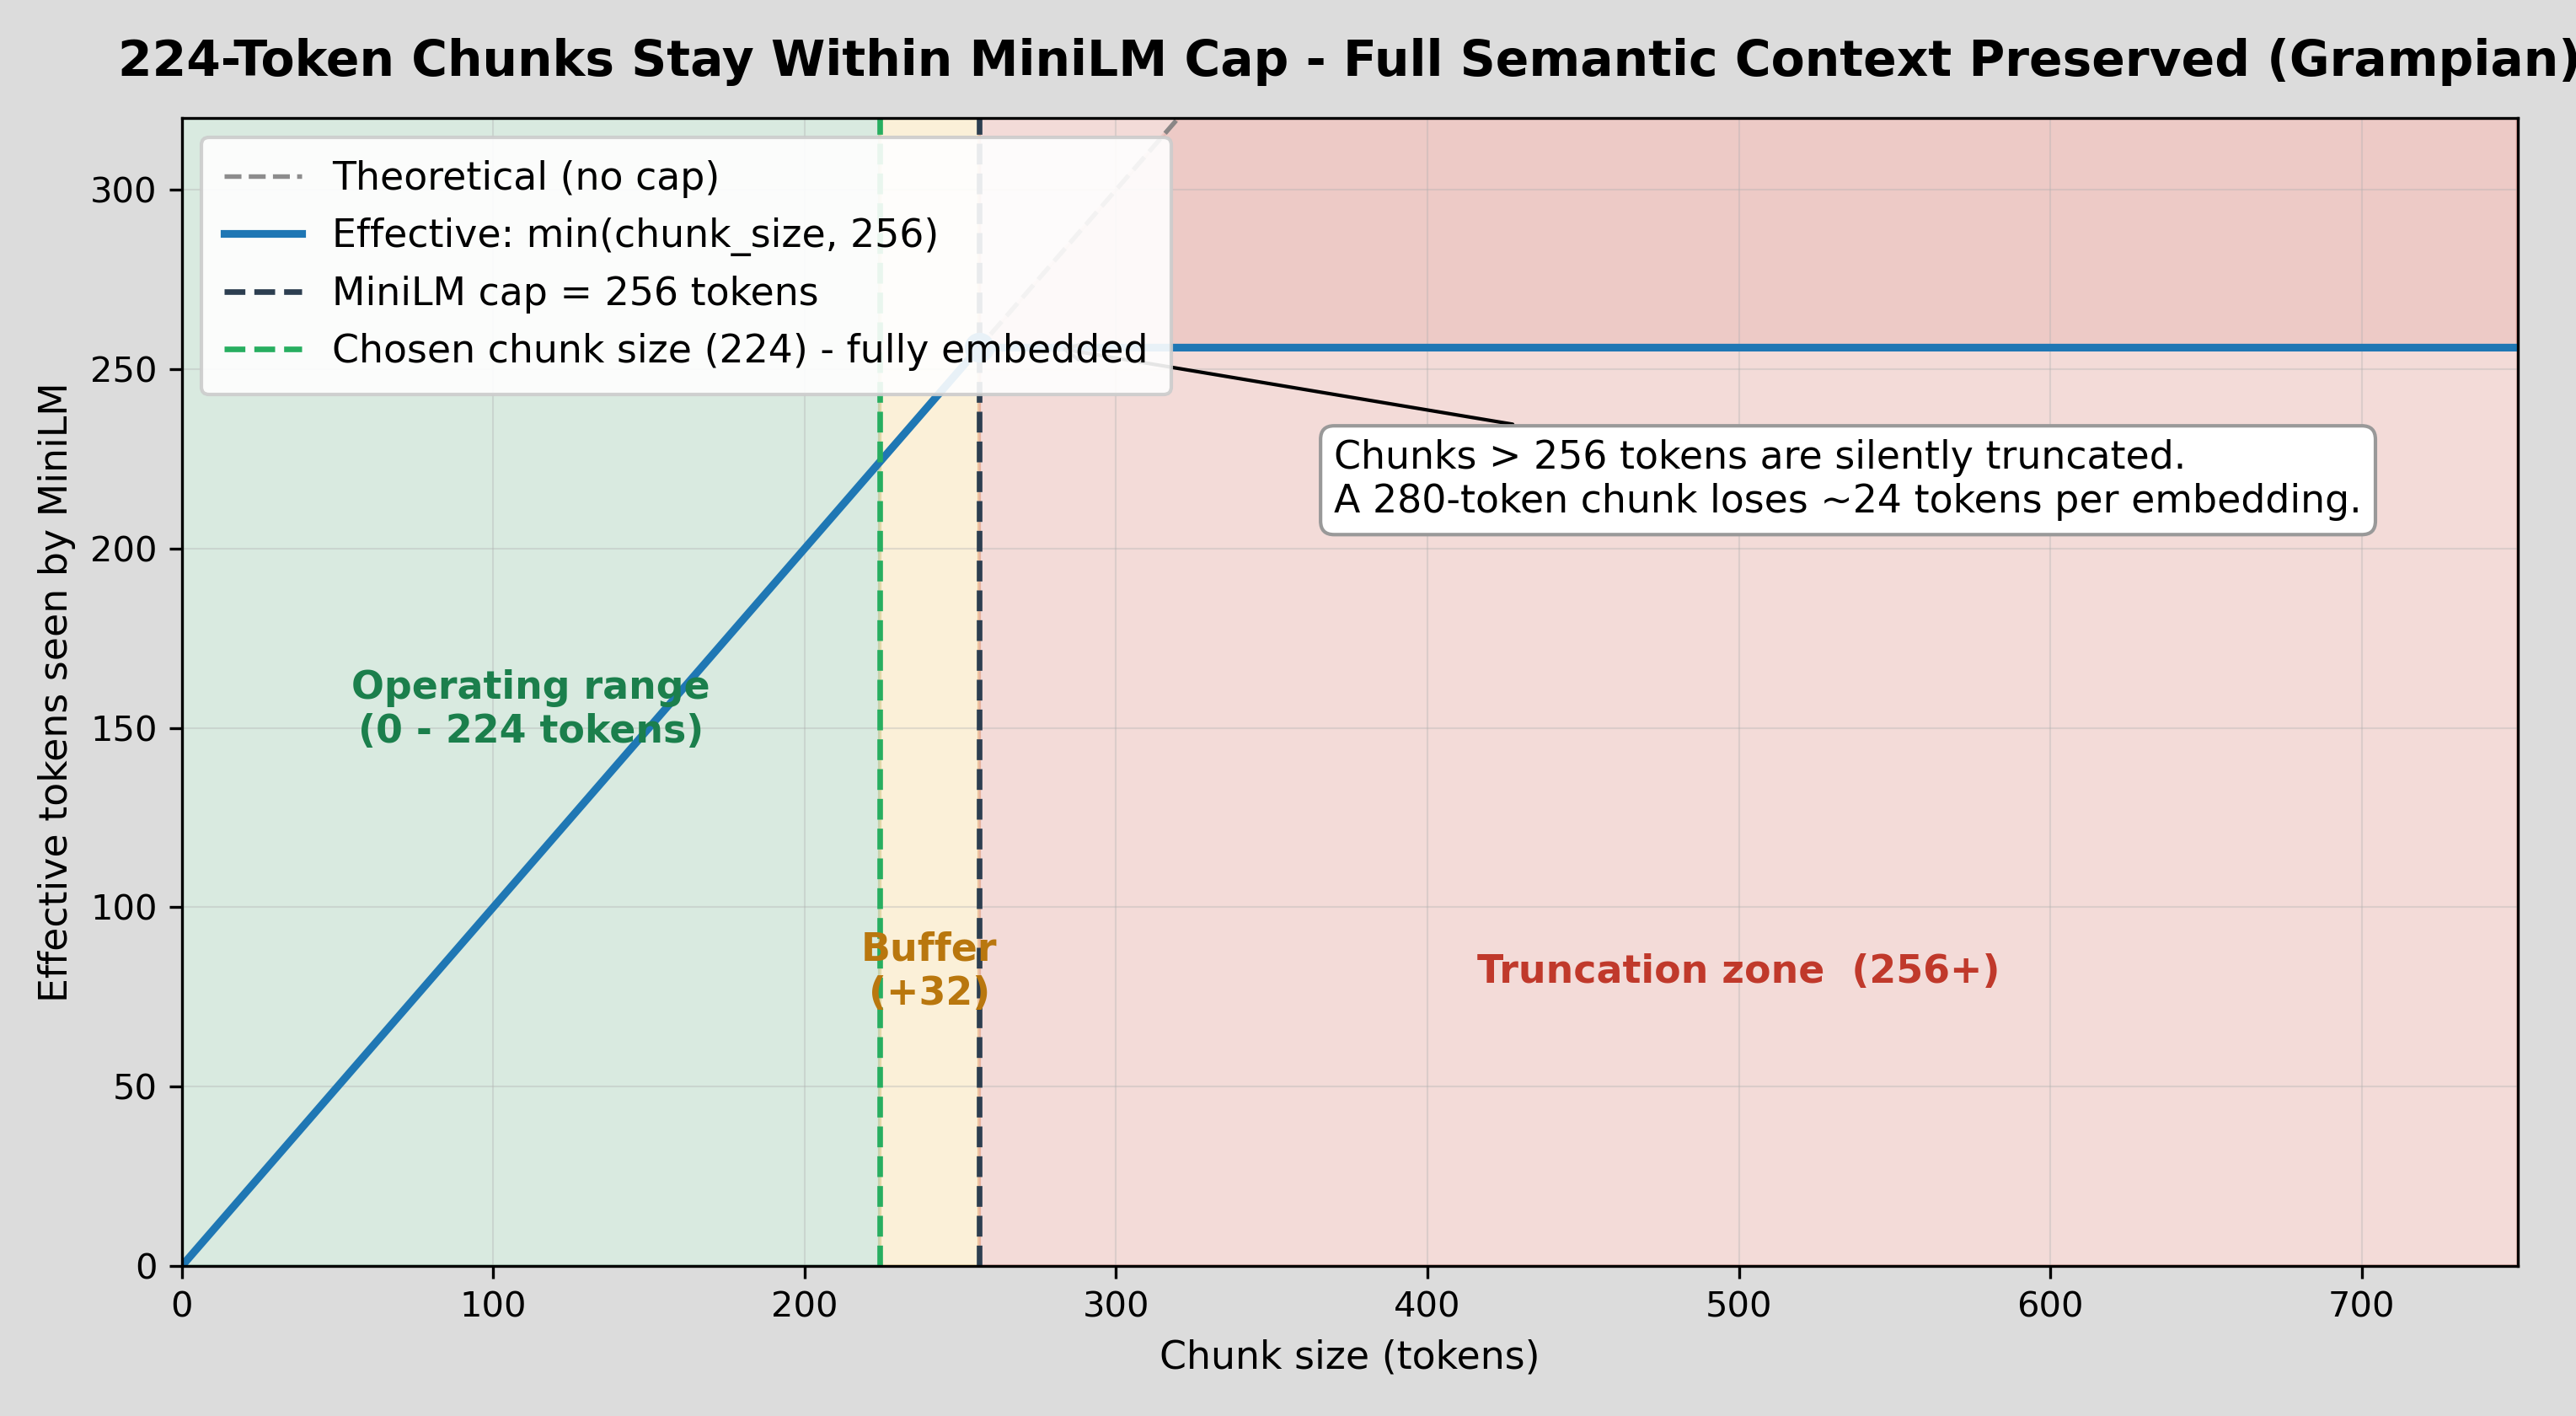

Figure A.1 — MiniLM effective embedding context vs chunk size.
Shaded region = truncation zone (chunk tokens > 256 are discarded before embedding).
Selected 224-token config provides a safety margin below the 256-token limit.


In [45]:
# Appendix B — MiniLM token cap figure.
# The figure was generated by scripts/plot_effective_embedding_context_minilm.py.
# It shows how increasing chunk size beyond 256 tokens does not increase the
# information encoded because MiniLM truncates inputs at 256 tokens.

from IPython.display import Image, display as ipy_display

cap_fig = REPO_ROOT / "docs" / "figures" / "effective_embedding_context_minilm_grampian.png"
if cap_fig.exists():
    ipy_display(Image(filename=str(cap_fig), width=700))
    print("Figure A.1 — MiniLM effective embedding context vs chunk size.")
    print("Shaded region = truncation zone (chunk tokens > 256 are discarded before embedding).")
    print("Selected 224-token config provides a safety margin below the 256-token limit.")
else:
    print(f"Figure not found: {cap_fig}")


### Appendix C — BM25 Parameter Grid Search

Thesis Table A.2: BM25 grid search over `k1 ∈ {0.5, 1.0, 1.2, 1.5, 2.0}` and `b ∈ {0.0, 0.25, 0.5, 0.75, 1.0}` (30 combinations, 250 queries).  
The promoted setting (`k1=1.5, b=0.75`) is the standard Okapi BM25 default; the performance gap to the best configuration is ΔMR R < 0.01.  
**Source:** `results/bm25_param_ablation_2026-04-19/results.json`

In [46]:
# Appendix C — BM25 parameter grid search (30 configurations, 250 queries).
import json as _json

bm25_abl = _json.loads(
    (REPO_ROOT / "results" / "bm25_param_ablation_2026-04-19" / "results.json").read_text()
)

# Flatten to a DataFrame: k1 × b → metrics
bm25_rows = []
for k1_str, b_dict in bm25_abl.items():
    for b_str, m in b_dict.items():
        bm25_rows.append({
            "k1": float(k1_str), "b": float(b_str),
            "Hit@1": m["hit@1"], "Hit@5": m["hit@5"], "MRR@10": round(m["mrr@10"], 4),
        })
bm25_grid = pd.DataFrame(bm25_rows).sort_values("MRR@10", ascending=False).reset_index(drop=True)
bm25_grid["Selected"] = ((bm25_grid["k1"] == 1.5) & (bm25_grid["b"] == 0.75)).map({True: "← thesis", False: ""})

print("Appendix C — BM25 parameter grid search (sorted by MRR@10)\n")
# Show top 5, promoted config, and bottom 2
top3  = bm25_grid.head(5)
promo = bm25_grid[bm25_grid["Selected"] == "← thesis"]
bot2  = bm25_grid.tail(2)
display_grid = pd.concat([top3, promo, bot2]).drop_duplicates().reset_index(drop=True)
print(display_grid.to_string(index=False))
print()
best_mrr = bm25_grid["MRR@10"].iloc[0]
prom_mrr = bm25_grid.loc[bm25_grid["Selected"] == "← thesis", "MRR@10"].values[0]
print(f"Best MRR@10   : {best_mrr:.4f}")
print(f"Promoted MRR  : {prom_mrr:.4f}  (k1=1.5, b=0.75 — Okapi BM25 standard defaults)")
print(f"Gap           : Δ = {best_mrr - prom_mrr:.4f}  (negligible; standard defaults chosen for reproducibility)")


Appendix C — BM25 parameter grid search (sorted by MRR@10)

 k1    b  Hit@1  Hit@5  MRR@10 Selected
2.0 1.00  0.724  0.888  0.7980         
1.5 1.00  0.724  0.880  0.7972         
1.2 0.75  0.728  0.884  0.7971         
1.2 1.00  0.720  0.876  0.7941         
1.0 0.75  0.724  0.884  0.7939         
1.5 0.75  0.708  0.884  0.7880 ← thesis
0.5 0.00  0.696  0.872  0.7717         
3.0 0.00  0.688  0.864  0.7650         

Best MRR@10   : 0.7980
Promoted MRR  : 0.7880  (k1=1.5, b=0.75 — Okapi BM25 standard defaults)
Gap           : Δ = 0.0100  (negligible; standard defaults chosen for reproducibility)


### Appendix D — Cross-Encoder Reranking Ablation

Thesis Table A.3: cross-encoder (`ms-marco-MiniLM-L-6-v2`) reranking over the 250-query evaluation set.  
CE top-$N$: candidates passed to the cross-encoder. $w$: CE score contribution weight.  
**Source:** `results/cross_encoder_ablation_2026-04-23/cross_encoder_ablation_summary.csv`

In [47]:
# Appendix D — Cross-encoder reranking ablation.
ce_df = pd.read_csv(
    REPO_ROOT / "results" / "cross_encoder_ablation_2026-04-23" / "cross_encoder_ablation_summary.csv"
)

# Mark baseline and best CE result
best_h1 = ce_df[ce_df["config"] != "baseline"]["Page Hit@1"].max()
ce_df["Note"] = ""
ce_df.loc[ce_df["config"] == "baseline",              "Note"] = "← hybrid base"
ce_df.loc[ce_df["Page Hit@1"] == best_h1, "Note"] = ce_df.loc[ce_df["Page Hit@1"] == best_h1, "Note"].apply(
    lambda x: (x + " " if x else "") + "← best CE"
)

base_h1 = ce_df.loc[ce_df["config"] == "baseline", "Page Hit@1"].values[0]
print("Appendix D — Cross-encoder reranking (ms-marco-MiniLM-L-6-v2, 250 queries)\n")
print(ce_df[["label", "Page Hit@1", "Page Hit@3", "Page Hit@5", "MRR@10", "Note"]].to_string(index=False))
print()
print(f"Best CE gain over baseline  : Δ Hit@1 = {best_h1 - base_h1:+.3f}")
oracle_gain = 0.764 - base_h1   # oracle subsection boost gain computed from Table 4.1
print(f"Oracle subsection-boost gain: Δ Hit@1 = {oracle_gain:+.3f}  (from Table 4.1)")
print(f"CE captures {abs((best_h1 - base_h1) / oracle_gain) * 100:.0f}% of the oracle gain —")
print("  structural signals (section labels) are the primary lever on this corpus.")


Appendix D — Cross-encoder reranking (ms-marco-MiniLM-L-6-v2, 250 queries)

          label  Page Hit@1  Page Hit@3  Page Hit@5  MRR@10          Note
  Hybrid (base)       0.676       0.856       0.888  0.7746 ← hybrid base
 CE top-5 w=0.2       0.736       0.864       0.896  0.8100     ← best CE
CE top-10 w=0.2       0.732       0.876       0.912  0.8110              
CE top-20 w=0.2       0.720       0.884       0.912  0.8088              
CE top-20 w=0.1       0.700       0.888       0.920  0.7975              
CE top-20 w=0.3       0.720       0.872       0.924  0.8071              

Best CE gain over baseline  : Δ Hit@1 = +0.060
Oracle subsection-boost gain: Δ Hit@1 = +0.088  (from Table 4.1)
CE captures 68% of the oracle gain —
  structural signals (section labels) are the primary lever on this corpus.


### Appendix E — Document-Constrained vs Global Retrieval

Thesis Table A.4: document-constrained retrieval (single-document FAISS index) vs global retrieval (all-document index).  
Global retrieval leaks chunks from other documents — the leakage rate grows from 30.8% at $k=1$ to 100% at $k=10$.  
**Source:** `results/thesis_validations/table_4_5_doc_vs_global_2026-04-20/comparison/doc_vs_global_scope_metrics.csv`

In [48]:
# Appendix E — Document-constrained vs global retrieval (250 queries).
dg_df = pd.read_csv(
    REPO_ROOT / "results" / "thesis_validations"
              / "table_4_5_doc_vs_global_2026-04-20"
              / "comparison" / "doc_vs_global_scope_metrics.csv"
)

# Compute delta columns
dg_df["Δ Hit@k"]  = (dg_df["doc_hit_rate"] - dg_df["global_hit_rate"]).round(3)
dg_df["Δ MRR"]    = (dg_df["doc_mrr"]       - dg_df["global_mrr"]).round(3)
dg_df["Leakage %"] = (dg_df["global_any_leakage_rate"] * 100).round(1)

out = dg_df.rename(columns={
    "k":                "k",
    "doc_hit_rate":     "Doc Hit@k",
    "global_hit_rate":  "Global Hit@k",
    "doc_mrr":          "Doc MRR",
    "global_mrr":       "Global MRR",
})[["k", "Doc Hit@k", "Global Hit@k", "Δ Hit@k", "Doc MRR", "Global MRR", "Δ MRR", "Leakage %"]]

print("Appendix E — Document-constrained vs global retrieval (250 queries)\n")
print(out.to_string(index=False))
print()
print("Δ = doc − global. Positive Δ means constrained retrieval is more accurate.")
print("Leakage % = fraction of queries where at least one returned chunk is from a different document.")
print()
k1_row = dg_df[dg_df["k"] == 1].iloc[0]
k10_row = dg_df[dg_df["k"] == 10].iloc[0]
print(f"At k=1:  constrained Hit@1 = {k1_row['doc_hit_rate']:.3f},  global = {k1_row['global_hit_rate']:.3f},  Δ = {k1_row['Δ Hit@k']:+.3f}")
print(f"At k=10: leakage reaches {k10_row['Leakage %']:.0f}% — all queries return at least one cross-document chunk.")
print("Document-constrained retrieval is used throughout the thesis to ensure evaluation integrity.")


Appendix E — Document-constrained vs global retrieval (250 queries)

 k  Doc Hit@k  Global Hit@k  Δ Hit@k  Doc MRR  Global MRR  Δ MRR  Leakage %
 1      0.752         0.588    0.164 0.748000    0.588000  0.160       30.8
 3      0.876         0.856    0.020 0.804667    0.706667  0.098       73.2
 5      0.912         0.932   -0.020 0.814067    0.723667  0.090       85.6
10      0.940         0.972   -0.032 0.817813    0.728737  0.089      100.0

Δ = doc − global. Positive Δ means constrained retrieval is more accurate.
Leakage % = fraction of queries where at least one returned chunk is from a different document.

At k=1:  constrained Hit@1 = 0.752,  global = 0.588,  Δ = +0.164
At k=10: leakage reaches 100% — all queries return at least one cross-document chunk.
Document-constrained retrieval is used throughout the thesis to ensure evaluation integrity.


### Appendix F — RAGAS Failure Examples

Thesis Table A.5: representative failure cases from the RAGAS end-to-end evaluation.  
All failures share a root cause: table linearisation loses the link between column headers, year identifiers, and numeric values.  
**Source:** `results/ragas/run75_224_generated/ragas_per_query.csv`

In [49]:
# Appendix F — RAGAS failure examples (faithfulness = 0, context_recall = 1).
# These are queries where the correct page WAS retrieved (recall = 1.0)
# but the LLM answer was unfaithful due to table linearisation artefacts.

ragas_pq = pd.read_csv(REPO_ROOT / "results" / "ragas" / "run75_224_generated" / "ragas_per_query.csv")

failures = ragas_pq[
    (ragas_pq["faithfulness"] == 0.0) &
    (ragas_pq["context_recall"] == 1.0)
][["user_input", "response", "faithfulness", "context_recall"]].head(5)

print("Appendix F — RAGAS failure examples (faithfulness=0, context_recall=1.0)\n")
print("All examples: correct page retrieved, but answer wrong due to table linearisation.\n")
for i, (_, row) in enumerate(failures.iterrows(), 1):
    q = str(row["user_input"])[:110]
    a = str(row["response"])[:80] if pd.notna(row["response"]) else "(no answer returned)"
    print(f"  [{i}] Q: {q}")
    print(f"       A: {a}")
    print(f"       faithfulness={row['faithfulness']:.1f}  context_recall={row['context_recall']:.1f}")
    print()

print("Root cause: table linearisation strips the link between column headers (e.g. £000 unit"),
print("labels), year row identifiers, and the numeric values in NHS financial tables.")
print("The retrieval stage is not at fault — all pages were correctly retrieved.")


Appendix F — RAGAS failure examples (faithfulness=0, context_recall=1.0)

All examples: correct page retrieved, but answer wrong due to table linearisation.

  [1] Q: How much did NHS Grampian actually spend against its core resource budget in 2020/21?
       A: 000
       faithfulness=0.0  context_recall=1.0

  [2] Q: Did NHS Grampian overspend or underspend its Core Revenue Resource Limit in 2020/21, and by how much?
       A: (no answer returned)
       faithfulness=0.0  context_recall=1.0

  [3] Q: What was the Total Revenue Resource Limit for 2020/21?
       A: 000
       faithfulness=0.0  context_recall=1.0

  [4] Q: What was the underlying surplus against the Core Revenue Resource Limit in 2020/21?
       A: £0.769m
       faithfulness=0.0  context_recall=1.0

  [5] Q: How much in efficiency savings did NHS Grampian deliver during 2020/21?
       A: 7
       faithfulness=0.0  context_recall=1.0

Root cause: table linearisation strips the link between column headers (e.g. £000 un